# <font color='orange'>TME ROBOTIQUE ET APPRENTISSAGE</font>
# <font color='orange'>3. Stratégies d'évolution pour la robotique collective</font>

# <font color="green">Version ETUDIANT·E·S 2025-2026</font>


*mise à jour: 26/3/2026*

Ce notebook doit être exécuté dans [Google Colab](colab.research.google.com/) ou dans Jupyter.

A la fin du TME, vous devez déposer votre travail sur Moodle:
* déposer votre notebook, avec le nom de fichier *obligatoirement* au format suivant: **RA_NOM1_NOM2.ipynb**
* toutes les cellules doivent être exécutées avec les graphes visibles
* un **bref** commentaire lorsque c'est demandé. Pour toutes les questions, une à deux phrases suffisent

*Le sujet est à faire en binome.*

# COMPLETEZ LES CHAMPS CI-DESSOUS AVEC NOM/PRENOM/CARTE_ETU:

* Étudiant 1: **_ZHANG_ _Yuxiang_ _21202829_**
* Étudiant 2: **_Alsafadi_ _Kenan_ _21502362_**




*contact: NB@SU 2024-03-28*


In [2]:
import numpy as np

#############################
### 0. Experimental setup ###
#############################

max_iterations = 5001

absolute_orientation = 0 #-90  # degrees
translation_per_step = 1.0 #1.0 # 6.0  # in [0,1]
max_translation_per_step = 1.0 # >0. pixel per move.
rotation_per_step = 0.0 # in [-1,1]
max_rotation_per_step = 3.0 # >0, in degrees

arena_size = 100 # 50
sensor_length = 10
nb_sensors = 8

particle_box = 3 # bounding box (square)

particle = np.zeros((particle_box, particle_box), dtype=int)

# Drawing a circle in the particle array
#particle_radius_real = particle_box / 2 - 0.5  # Radius of the circle in the particle
#center_particle_real = (particle_box / 2 - 0.5, particle_box / 2 - 0.5)  # Real center of the particle
particle_radius_real = particle_box / 2.0  # Radius of the circle in the particle
center_particle_real = (particle_box / 2 - 0.5, particle_box / 2 - 0.5)  # Real center of the particle

####################
### 1. Structure ###
####################

def init(): # perform only once
  global particle,center_particle_real,particle_radius_real,robots_count

  for i in range(particle.shape[0]):
      for j in range(particle.shape[1]):
          # Check if the cell falls within the circle radius
          if ((i - center_particle_real[0])**2 + (j - center_particle_real[1])**2) <= particle_radius_real**2:
              particle[i, j] = 2
          else:
            particle[i, j] = 3

  init_arena()
  init_trace()
  init_occupancy()

  robots_count = 1

def init_arena():
  global arena
  arena = np.zeros((arena_size, arena_size), dtype=int)

def init_trace():
  global trace
  trace = np.zeros((arena_size, arena_size), dtype=int)

def init_occupancy():
  global occupancy
  occupancy = np.zeros((arena_size, arena_size), dtype=int)

def clear_arena(): # clear content, except for wall
  global arena
  #arena[:] = 0
  arena[arena != 1] = 0

def clear_trace(): # clear content, except for wall
  global trace
  #trace[:] = 0
  trace[trace != 1] = 0

def clear_occupancy(): # clear content
  global occupancy
  occupancy[:,:] = 0

def draw_line(x1, y1, x2, y2, color): # do not draw on wall
    global arena
    num_points = max(abs(x2 - x1), abs(y2 - y1)) + 1
    x_points = np.linspace(x1, x2, num_points, dtype=int)
    y_points = np.linspace(y1, y2, num_points, dtype=int)
    # shorte, not border-protected:
    # arena[y_points, x_points] = color
    # longer, border-protected:
    for i in range(len(x_points)):
      if y_points[i] >= 0 and y_points[i] < arena.shape[0] and x_points[i] >= 0 and x_points[i] < arena.shape[1]:
        if arena[y_points[i],x_points[i]] != 1:
          arena[y_points[i],x_points[i]] = color

def cast_sensor(x1, y1, x2, y2, color=6):
    global arena, display_cast
    num_points = max(abs(x2 - x1), abs(y2 - y1)) + 1
    x_points = np.linspace(x1, x2, num_points, dtype=int)
    y_points = np.linspace(y1, y2, num_points, dtype=int)
    max_distance = math.sqrt( (x_points[0]-x_points[-1])**2 + (y_points[0]-y_points[-1])**2 ) - particle_radius_real
    for i in range(len(x_points)):
      if y_points[i] >= 0 and y_points[i] < arena.shape[0] and x_points[i] >= 0 and x_points[i] < arena.shape[1]:
        if arena[y_points[i],x_points[i]] == 1 or arena[y_points[i],x_points[i]] == 2  or arena[y_points[i],x_points[i]] == 4:
          if verbose:
            print ("DETECT OBJECT at",i)
          return ( math.sqrt( (x_points[0]-x_points[i])**2 + (y_points[0]-y_points[i])**2 ) - particle_radius_real ) / max_distance # distance to obstacle, normalize in [0,1]
        elif display_cast == True:
          arena[y_points[i],x_points[i]] = color
    return 1.0

translation_per_step = 0.0  # in units
rotation_per_step = 0.0  # in degrees

############################
### 2. General functions ###
############################

def create_wall(x1, y1, x2, y2):
    arena[max(y1, 0):min(y2, arena_size), max(x1, 0):min(x2, arena_size)] = 1
    if display_trace:
      trace[max(y1, 0):min(y2, arena_size), max(x1, 0):min(x2, arena_size)] = 1

def get_sensors(x, y, theta): # 8 sensors belt
    global sensor_length, nb_sensors

    source_x, source_y = int(x+particle_radius_real-1), int(y+particle_radius_real-1)

    sensor_values = []
    for i in range(nb_sensors):
      offset_x = math.cos(math.radians(theta+i*360.0/nb_sensors)) * sensor_length
      offset_y = math.sin(math.radians(theta+i*360.0/nb_sensors)) * sensor_length
      target_x = int(source_x + offset_x + 0.5)
      target_y = int(source_y - offset_y + 0.5)
      sensor_values.append( cast_sensor(int(source_x),int(source_y),target_x,target_y,6) )

    return sensor_values

def clean_sensors(x, y, theta): # 8 sensors belt
    global sensor_length, nb_sensors

    if display_cast == False:
      return

    source_x, source_y = int(x+particle_radius_real-1), int(y+particle_radius_real-1)

    sensor_length = 10
    nb_sensors = 8

    sensor_values = []
    for i in range(nb_sensors):
      offset_x = math.cos(math.radians(theta+i*360.0/nb_sensors)) * sensor_length
      offset_y = math.sin(math.radians(theta+i*360.0/nb_sensors)) * sensor_length
      target_x = int(source_x + offset_x + 0.5)
      target_y = int(source_y - offset_y + 0.5)
      draw_line(int(source_x),int(source_y),target_x,target_y,0)

    return sensor_values

def place_particle(x, y, theta, robot_id):
    global arena, particle
    x, y = int(x), int(y)
    arena_slice = arena[y:y+particle_box, x:x+particle_box]

    # Check for overlap between particle and non-zero cells in the arena
    #collision = np.logical_and(arena_slice == 1, particle == 2)
    collision = np.logical_and(arena_slice != 0, particle == 2) # 2024-03-25
    if np.any(collision):
        collision_array = np.where(collision, 3, particle)
        return collision_array

    #arena_slice[ int(math.cos(theta)*particle_box/2) , int(math.sin(theta)*particle_box/2) ] = 3 # display particle front
    #arena[y:y+particle_box, x:x+particle_box] += np.where(arena_slice == 0, particle, 0)

    for i in range(particle_box):
      for j in range(particle_box):
        if arena[y+i, x+j] == 0 or arena[y+i, x+j] == 4 or arena[y+i, x+j] == 6:
          arena[y+i, x+j] = 2

    trace[int(y + particle_box / 2.),int(x + particle_box / 2.)] = 2
    occupancy[int(y + particle_box / 2.),int(x + particle_box / 2.)] = robot_id

    if verbose:
      print("location",x+particle_box/2.0,y+particle_box/2.0)
      print("absolute_orientation", theta)

    offset_x = math.cos(math.radians(theta)) * particle_box / 2.0 * .999
    offset_y = math.sin(math.radians(theta)) * particle_box / 2.0 * .999
    x_head = int(x + particle_box / 2. + offset_x )
    y_head = int(y + particle_box / 2. - offset_y )
    if verbose:
      print ("y_head, x_head",y_head, x_head)

    arena[y_head, x_head] = 4  # Display particle front

    return None

def erase_particle(x, y):
    global arena, particle
    x, y = int(x), int(y)
    #arena[y:y+particle_box, x:x+particle_box] -= particle * (arena[y:y+particle_box, x:x+particle_box] != 0)
    for i in range(particle_box):
      for j in range(particle_box):
        if arena[y+i, x+j] == 2 or arena[y+i, x+j] == 4:
          arena[y+i, x+j] = 0

def draw(arena,double_size=False):

    if double_size == True:
      doubled_figsize = (12.8, 9.6)
      plt.figure(figsize=doubled_figsize)

    cmap = colors.ListedColormap(['white', 'black', 'grey', 'red', 'orange', 'green'])
    bounds = [0, 1, 2, 3, 4, 5, 6]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    plt.imshow(arena, cmap=cmap, norm=norm)
    plt.colorbar(ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], format=plt.FuncFormatter(lambda x, _: {0.5: '0 - nothing', 1.5: '1 - obstacle', 2.5: '2 - robot', 3.5: '3 - collision', 4.5: '4 - robot front', 5.5: '5 - sensor ray'}[x]))
    plt.show()

def show_arena():
  draw(arena,double_size=False)

def show_trace():
  draw(trace,double_size=False)


####################################
### 3. PARTICLE UPDATE functions ###
####################################

def update_particle_position(x, y, theta, translation_per_step, rotation_per_step, iteration, noiseFlag = False):
  '''
  Function called to update particle position (and orientation). It should merge the desired control command from the user (translation_per_step and rotation_per_step) and the physics of environment and particle.
  Below is a simple example where desired translation and rotation per step are applied directly (ideal: no friction, unbounded bang-bang controller)
  Add whatever you need as persistent internal data.

  # x, y: position of the particle (real values)
  # theta (absolute_orientation): particle absolute orientation wrt an external referential (0° points rightward, trigonometric, use degree)
  # translation_per_step, rotation_per_step: *desired* value by the controller/user. I.e.: values are applied if no friction, no inertia, no collision (see example below)
  # iteration: simulator iteration number (may be ignored)
  '''

  new_orientation = theta + rotation_per_step

  # Sinusoidal noise for rotation (optional)
  if noiseFlag == True:
    noise = 10 * math.sin(2 * math.pi * iteration / 5)
    new_orientation += noise

  # Convert orientation to radians for calculation
  orientation_radians = math.radians(new_orientation)

  new_x = x + translation_per_step * math.cos(orientation_radians)
  new_y = y - translation_per_step * math.sin(orientation_radians)  # Minus sign due to y-axis inversion in image coordinates

  return new_x, new_y, new_orientation


def update_particle_dynamics(x, y, absolute_orientation, translation_per_step, rotation_per_step, iteration, collision_array ):
  '''
  Function called to udpate internal data (to be defined here) in case of a collision event.
  This function does not move the robot. Updating the absolute_orientation is possible, as well as (to be defined) internal data structure (e.g. encoding the effect of inertia)
  Note that when a particle experience a collision, the collision is recorded (see collision_array) and move is cancelled.
  The goal of this function is to compute/update all necessary information to call later the update_particle_position function.
  Add whatever you need as persistent internal data.

  # x, y: position of the particle (real values)
  # absolute_orientation: particle absolute orientation wrt an external referential (0° points rightward, trigonometric, use degree)
  # translation_per_step, rotation_per_step: *desired* value by the controller/user. I.e.: values are applied if no friction, no inertia, no collision (see example below)
  # iteration: simulator iteration number (may be ignored)
  # iteration: simulator iteration number (may be ignored)
  # collision_array: integer array showing the particle state within its bounding box. 0 for nothing, 1 for particle elements, 2 for particle elements experiencing a collision event

  Testing: essaye avec translation_per_step=1.0, puis avec translation_per_step=6.0 (cas intéressant du a la faible épaisseur du mur)
  '''

  # do nothing for now.

  return absolute_orientation


#######################
### 4. Main loop    ###
#######################


robots_count = 1

class Robot:
    x0, y0, theta_0, x,y,theta = 0,0,0,0,0,0
    id = -1
    log_sum_of_translation = 0 # logging
    log_sum_of_rotation = 0 # logging

    def __init__(self, x_0, y_0, theta_0):
      global robots_count
      self.x0 = self.x = x_0
      self.y0 = self.y = y_0
      self.theta0 = self.theta = theta_0
      self.id = robots_count
      robots_count = robots_count + 1

    def reset(self):
      self.x = self.x0
      self.y = self.y0
      self.theta = self.theta0
      self.log_sum_of_translation = 0
      self.log_sum_of_rotation = 0

    def step(self,sensors):
      translation, rotation = 0,0
      return translation, rotation

# parameters
  # initial x and y position and orientation
  # step controller function which returns translation/rotation (in [-1,1]) from sensors (in [0,1])
# returns:
  # sum of actual translations in [0,1]. Normalized over time and max translation.
  # sum of rotation, absolute value normalized value in [0,1]. Normalized over time and max rotation.
  # number of pixels of arena visited (unique location, ie. visited twice counts as 1)
  # particle's x coordinate at the end
  # particle's y coordinate at the end
def simulate(my_robots):
  global x_particle,y_particle,absolute_orientation,trace,occupancy

  clear_arena()
  clear_trace()
  clear_occupancy()

  for k in range(len(my_robots)):
    #k = 0
    #x_particle, y_particle = x0, y0
    #absolute_orientation = orientation0
    #sensors = get_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
    collision_array = place_particle(my_robots[k].x, my_robots[k].y, my_robots[k].theta, my_robots[k].id)

    if collision_array is not None:
      print("[ERROR] initial location triggers collision.")
      sys.exit()

  iteration = 0

  while iteration < max_iterations:
      if verbose_minimal_progress == True and iteration%gap_between_display_minimal_progress == 0:
        print ("### iteration",iteration,"/",max_iterations,"###")

      for k in range(len(my_robots)):

        # necessary to update sensors as the world may have changed
        erase_particle(my_robots[k].x, my_robots[k].y)
        clean_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
        sensors = get_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
        #place_particle(my_robots[k].x, my_robots[k].y, my_robots[k].theta, my_robot[k].id)

        translation_per_step,rotation_per_step = my_robots[k].step(sensors)

        my_robots[k].log_sum_of_rotation += abs((max(-1.,min(+1.,rotation_per_step)))) # logging

        #erase_particle(my_robots[k].x, my_robots[k].y)
        #clean_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
        backup_x_particle, backup_y_particle = my_robots[k].x, my_robots[k].y
        my_robots[k].x, my_robots[k].y, my_robots[k].theta = update_particle_position(my_robots[k].x, my_robots[k].y, my_robots[k].theta, (max(-1.,min(+1.,translation_per_step)))*max_translation_per_step, (max(-1.,min(+1.,rotation_per_step)))*max_rotation_per_step, iteration ,noiseFlag=False)
        sensors = get_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
        collision_array = place_particle(my_robots[k].x, my_robots[k].y, my_robots[k].theta, my_robots[k].id)
        if collision_array is not None: # collision occured
            if verbose == True:
                print("Collision detected!")
            if display_collision:
                print(collision_array)
            clean_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
            my_robots[k].x, my_robots[k].y = backup_x_particle, backup_y_particle
            sensors = get_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
            if display_collision:
                draw(collision_array)  # Draw the collision array
            my_robots[k].theta = update_particle_dynamics(my_robots[k].x, my_robots[k].y, my_robots[k].theta, (max(-1.,min(+1.,translation_per_step)))*max_translation_per_step, (max(-1.,min(+1.,rotation_per_step)))*max_rotation_per_step, iteration, collision_array)
            place_particle(my_robots[k].x, my_robots[k].y, my_robots[k].theta, my_robots[k].id)
            if verbose:
                print("Backtrack")

        if my_robots[k].x != backup_x_particle or my_robots[k].y != backup_y_particle:
          my_robots[k].log_sum_of_translation += math.sqrt( ( my_robots[k].x - backup_x_particle )**2 + ( my_robots[k].y - backup_y_particle)**2 )  # logging

      if display_arena == True:
        draw(arena)  # Draw the arena at each step
      if verbose == True:
        print(arena)
      iteration = iteration + 1

  log_pixels_visited = np.sum(trace == 2)

  log_total_sum_of_translation, log_total_sum_of_rotation = 0,0
  for k in range(len(my_robots)):
    log_total_sum_of_translation += my_robots[k].log_sum_of_translation
    log_total_sum_of_rotation += my_robots[k].log_sum_of_rotation

  retValues = {
      "translations": log_total_sum_of_translation/max_iterations,
      "rotations": log_total_sum_of_rotation/max_iterations,
      "coverage": log_pixels_visited/(arena_size**2)
      #"x_pos_end": x_particle,
      #"y_pos_end": y_particle,
      #"theta_end": absolute_orientation
  }

  return retValues


#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")


 2026-03-26 17:56:24 GMT
OK.


---
---
---

# <font color='orange'>PREAMBULE: initialisation</font>

# Simulateur robot

Il n'est pas nécessaire de regarder le code de ces cellules, elles sont utiles pour les fonctions utilisées dans les parties suivantes.

Remarque: *il suffit d'exécuter ces cellules une seule fois par instance de noyau.*

In [1]:
from datetime import datetime
from datetime import date
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import numpy as np
import math
import random
import sys

!pip install cma
import cma

#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip

 2026-03-26 17:56:22 GMT
OK.


# Fonctions utiles (construction d'arènes)

Exécutez. Vous pouvez étudier, voire étendre le contenu.

Remarque: create_arena_walls() doit être appelé systématiquement lors de la création d'une nouvelle arène.


In [5]:

def create_arena_walls(): # arena walls are *mandatory* to enclose the robot into a closed arena (otherwise: code will fail with out-of-bounds at some point)
  global arena_size
  create_wall(0, 0, arena_size, 1)
  create_wall(0, arena_size-1, arena_size, arena_size)
  create_wall(0, 0, 1, arena_size)
  create_wall(arena_size-1, 0, arena_size, arena_size)

def create_wall_1():
  global arena_size
  create_wall(arena_size//2+13, arena_size//2-10, arena_size//2+16, arena_size//2+10)

def create_wall_2(y_shift=0):
  global arena_size
  create_wall(arena_size//2+13, arena_size//2-10+y_shift, arena_size//2+16, arena_size//2+10+y_shift)
  create_wall(arena_size//2-16, arena_size//2-10+y_shift, arena_size//2-13, arena_size//2+10+y_shift)
  create_wall(arena_size//2-13, arena_size//2-10+y_shift, arena_size//2+13, arena_size//2-7+y_shift)
  create_wall(arena_size//2-13, arena_size//2+7+y_shift, arena_size//2-2, arena_size//2+10+y_shift)
  create_wall(arena_size//2+3, arena_size//2+7+y_shift, arena_size//2+13, arena_size//2+10+y_shift)

#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")


 2026-03-26 17:56:38 GMT
OK.


# Initialisation des paramètres expérimentaux et des options recommandées d'affichage de messages

In [3]:
# experimental settings

arena_size = 100
max_translation_per_step = 1.0 # >0. pixel per move.
max_rotation_per_step = 10.0 # >0, in degrees
max_iterations = 5001 # nb of simulator iterations for evaluating one robot

# default values for display debug (may be changed later)

verbose_minimal_progress = True # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
gap_between_display_minimal_progress = int(max_iterations/5) # used if verbose_minimal_progress = True
verbose = False # suggested: False -- used for debug
display_collision = False # suggested: False -- used for debug
display_arena = False # suggested: False -- if True, display arena for *all* iterations
display_trace = True # suggested: True
display_cast = False # suggested: False -- if True, display sensor ray casting for *all* iterations (even w/o display)

#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")


 2026-03-26 17:56:26 GMT
OK.


---
---
---

#<font color="orange">Partie 1. Prise en main : simulation robotique collective</font>

Le robot dispose de 8 senseurs (tous ne seront pas utilisés dans la suite) et de deux commandes motrices (translation et rotation). Toutes les commandes sont normalisées (senseurs dans [0,1], translation et rotation dans [-1,+1]).

Les dimensions du robot sont de 2x2 unités. Une unité correspond à un pixel. Cependant, même si l'affichage est discret, le robot se déplace de manière continue dans l'environnement (position/orientation sont des valeurs réelles). La gestion des collisions est faîtes de manière discrète, les déplacements et la mise à jour des valeurs senseurs est faite sur la base de valeurs continues.

La structure des senseurs est la suivante:
  - [0] avant
  - [1] avant-gauche
  - [2] gauche
  - [3] arrière-gauche
  - [4] arrière
  - [5] arrière-droite
  - [6] droite
  - [7] avant-droite

L'orientation est définie comme suit:
  - *absolute_orientation* est utilisé à l'initialisation pour positionner le robot. la valeur 0 indique que le robot pointe vers la droite de l'arène. =-90 vers le bas. etc. (sens trigonométrique)
  - *rotation* est une commande motrice du robot. Elle s'exprime dans le sens trigonométrique (le robot tourne à gauche si inférieure à 0). Elle est définie entre -1 et +1. Cependant, la rotation effective dépend du paramètre * max_rotation_per_step* (non modifiable), qui donne l'angle de rotation maximum possible entre deux itérations du simulateur.
  - exemple: une rotation de -1.0 sachant que max_rotation_per_step=10 provoque une rotation dans le sens inverse des aiguilles d'une montre de 10° par itération.

La translation est définie comme suit:
  - entre -1 (vitesse max. en arrière) et 1 (vitesse max. en avant). pas de déplacement si la translation vaut 0.
  - la translation effective dépend du paramètre *max_translation_per_step* (non modifiable) qui donne le nombre d'unité de déplacement maximum par itération de l'algorithme.
  - exemple: une translation de -0.5 sachant que max_translation_per_step=10 provoque une translation vers l'arrière de 5 unités par itération.
  - Remarque: la notion d'avant et d'arrière est arbitraire. En pratique, cette asymétrie est une interprétation que nous faisons en observant le comportement. En particulier, le résultat d'une optimisation peut *vous* donner l'*impression* que le robot se déplace en reculant (cf. suite du sujet), mais cette observation n'a pas de sens du point de vue du robot (en particulier si les senseurs sont disposés de manière symétrique, ce qui est le cas ici).

<font color="red">EXERCICES:</font>

- Etudiez et exécutez les deux cellules suivantes. La première montre comment programmer plusieurs robots et simuler un environnement. La seconde, plus pertinente pour la suite, montre comment implémenter un réseau de neurones artificiels simples pour le contrôle d'un robot, puis la création de plusieurs robots dont les paramètres de réseaux de neurones sont tirés au hasard, puis testé en simulation. Vous observerez en particulier les informations sur le nombre de "cellules" couvertes, c'est à dire le nombre d'endroits dans l'arène ou un robot est passé en dernier.



# Des robots controllés par un comportement fixe: explorateurs et allons-tout-droit

#
# Multi-robots - ad hoc controllers 
#
### iteration 0 / 501 ###

Statistiques:
	 translations      : 1.5085435683608452
	 rotations         : 0.21849658041988648
	 couverture        : 0.0613

  Robot #1 captured 354 cells
  Robot #2 captured 255 cells
  Robot #3 captured 2 cells
  Robot #4 captured 2 cells
# Final state


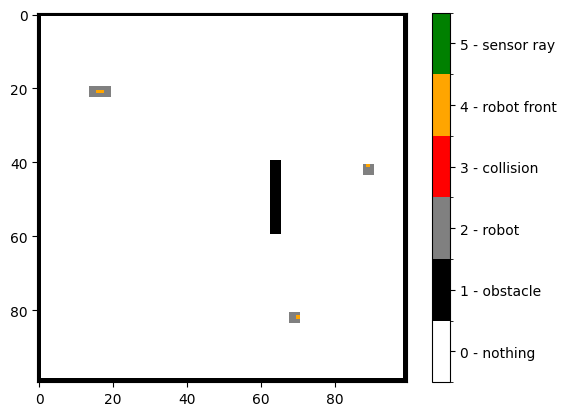

# Trajectory


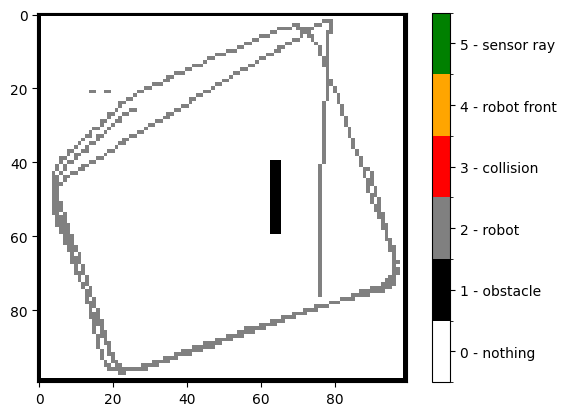

In [6]:
# policy function


class Robot_Explorer(Robot):
  def step(self,sensors):
    translation = sensors[0]
    rotation = 1.0*sensors[1] - 1.0*sensors[-1] + (random.random()-0.5)*0.1
    return translation, rotation

class Robot_Dumb(Robot):
  def step(self,sensors):
    translation = 1.0
    rotation = 0.
    return translation, rotation

# Main

init()

print ("#\n# Multi-robots - ad hoc controllers \n#")

max_iterations = 501

display_arena=False # diplay step-by-step if True.
verbose_minimal_progress = True # suggested: True -- useful. Tune gap_between_... to limit the nb of messages

#clear_arena()
create_arena_walls()
create_wall_1()

#theta_init = 0

nb_robots = 4
robots = []
x_center = arena_size//2 - particle_box/2
y_center = arena_size//2 - particle_box/2

robots.append( Robot_Explorer( arena_size//4,arena_size//4, random.randint(-180,180) ) )
robots.append( Robot_Explorer( 3*arena_size//4, 3*arena_size//4, 90 ) )

robots.append( Robot_Dumb( 13, 20, 0 ) )
robots.append( Robot_Dumb( 18, 20, 180 ) )

retValues = simulate(robots)

print ()
print ("Statistiques:")
print ("\t translations      :", retValues['translations']) # Somme des valeurs absolues de translations. valeurs normalisées entre 0 et 1.
print ("\t rotations         :", retValues['rotations']) # Somme des valeurs absolues de rotations. Valeur normalisée entre 0 et 1.
print ("\t couverture        :", retValues['coverage']) # taux de couverture. Valeur normalisée entre 0 et 1 (arène entièrement couverte).
print ()

robot_ids, visited_cells = np.unique(occupancy, return_counts=True)
for value, count in zip(robot_ids, visited_cells):
  if value != 0:
    print(f"  Robot #{value} captured {count} cells")


print ("# Final state")
show_arena()

print ("# Trajectory")
show_trace()


# Des robots controllés par réseaux de neurones avec paramètres fixés au hasard

#
# Multi-robots - random search on ANN controller
#
Robot no. 1 is alive
Robot no. 2 is alive
Robot no. 3 is alive
Robot no. 4 is alive
run no. 1 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 2.172741432557533, 'rotations': 2.8639008380444837, 'coverage': np.float64(0.0468)}


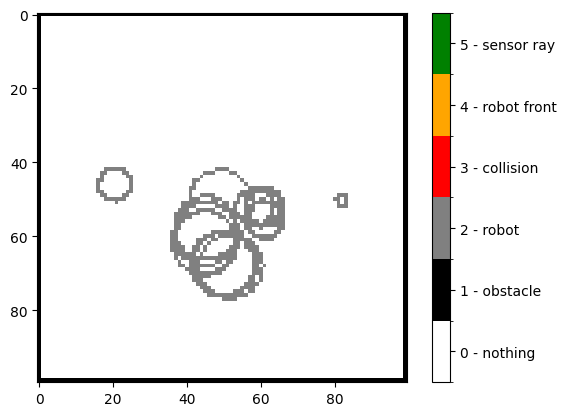

Grid occupancy per robot:
  Robot #1 captured 35 cells
  Robot #2 captured 305 cells
  Robot #3 captured 117 cells
  Robot #4 captured 11 cells
run no. 2 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 2.7378629185984673, 'rotations': 3.1692618037600946, 'coverage': np.float64(0.0185)}


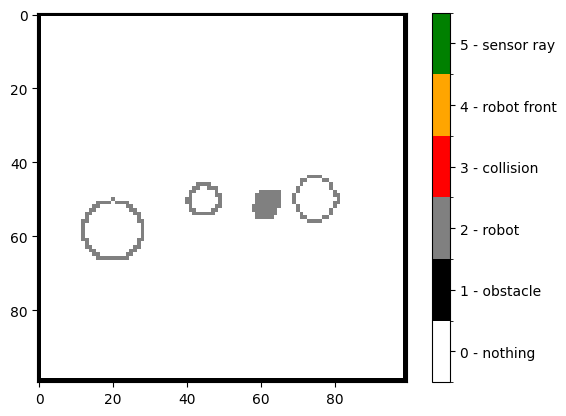

Grid occupancy per robot:
  Robot #1 captured 62 cells
  Robot #2 captured 34 cells
  Robot #3 captured 53 cells
  Robot #4 captured 36 cells
run no. 3 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 2.3521268895679133, 'rotations': 2.425522678343434, 'coverage': np.float64(0.0468)}


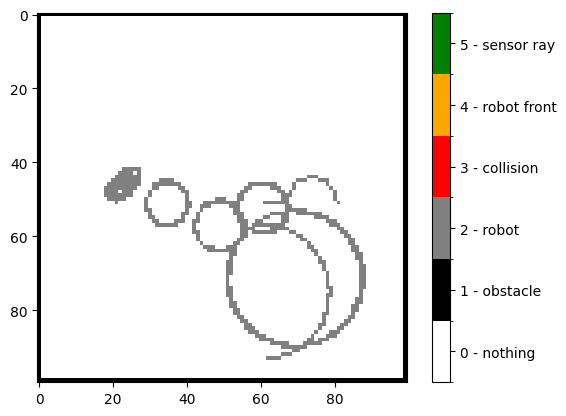

Grid occupancy per robot:
  Robot #1 captured 64 cells
  Robot #2 captured 49 cells
  Robot #3 captured 228 cells
  Robot #4 captured 127 cells
run no. 4 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 1.4141065303305742, 'rotations': 1.9572472567035226, 'coverage': np.float64(0.0571)}


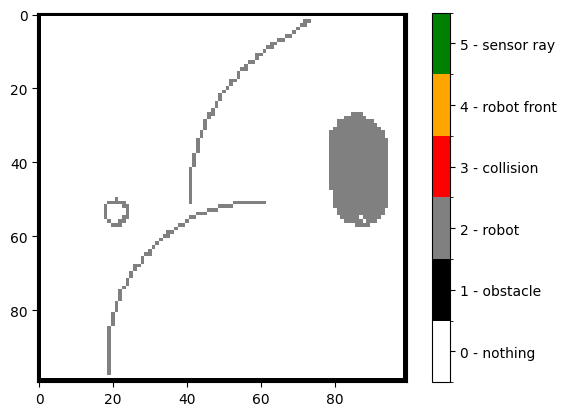

Grid occupancy per robot:
  Robot #1 captured 22 cells
  Robot #2 captured 61 cells
  Robot #3 captured 68 cells
  Robot #4 captured 420 cells
run no. 5 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 2.6866296288967675, 'rotations': 3.0196986238300747, 'coverage': np.float64(0.0199)}


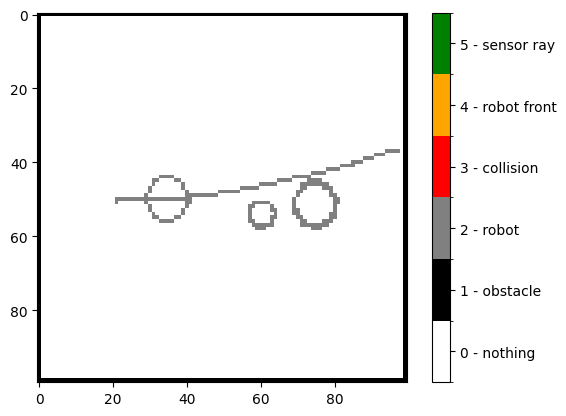

Grid occupancy per robot:
  Robot #1 captured 77 cells
  Robot #2 captured 36 cells
  Robot #3 captured 28 cells
  Robot #4 captured 58 cells
run no. 6 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 2.9653475322823843, 'rotations': 2.6577620008717586, 'coverage': np.float64(0.0585)}


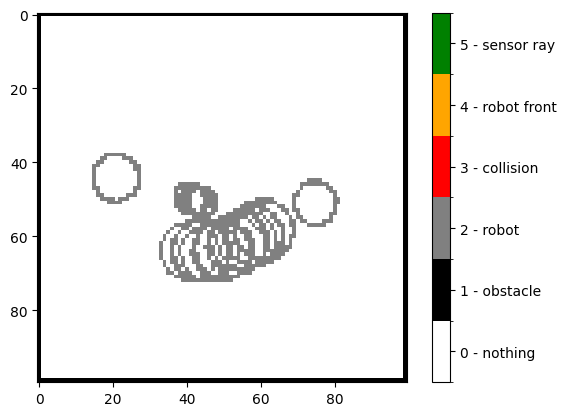

Grid occupancy per robot:
  Robot #1 captured 52 cells
  Robot #2 captured 86 cells
  Robot #3 captured 399 cells
  Robot #4 captured 48 cells
run no. 7 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 3.1679196414496746, 'rotations': 3.6247804624782956, 'coverage': np.float64(0.0178)}


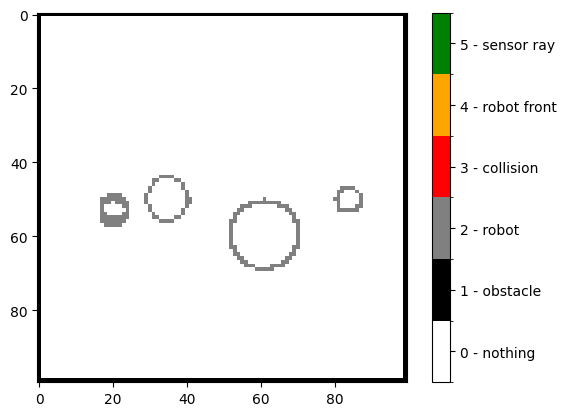

Grid occupancy per robot:
  Robot #1 captured 47 cells
  Robot #2 captured 36 cells
  Robot #3 captured 72 cells
  Robot #4 captured 23 cells
run no. 8 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 2.182475824353178, 'rotations': 2.7538894079721343, 'coverage': np.float64(0.0155)}


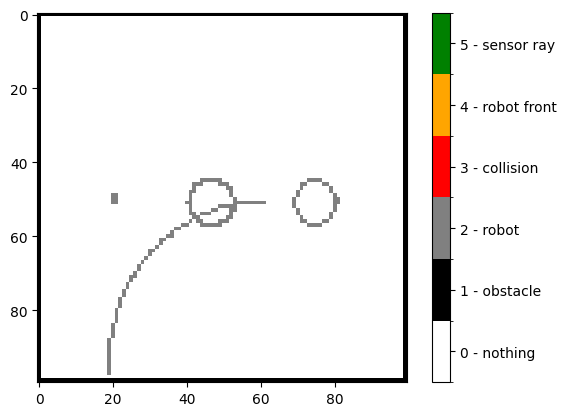

Grid occupancy per robot:
  Robot #1 captured 6 cells
  Robot #2 captured 47 cells
  Robot #3 captured 66 cells
  Robot #4 captured 36 cells
run no. 9 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 3.5726862502494225, 'rotations': 3.174367355889025, 'coverage': np.float64(0.0732)}


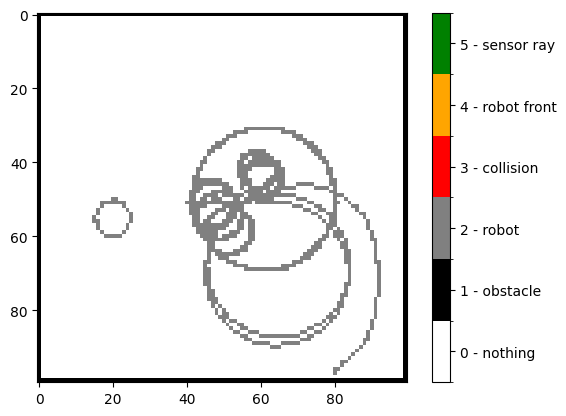

Grid occupancy per robot:
  Robot #1 captured 31 cells
  Robot #2 captured 156 cells
  Robot #3 captured 98 cells
  Robot #4 captured 447 cells
run no. 10 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 3.164066081972145, 'rotations': 3.82979665688201, 'coverage': np.float64(0.0337)}


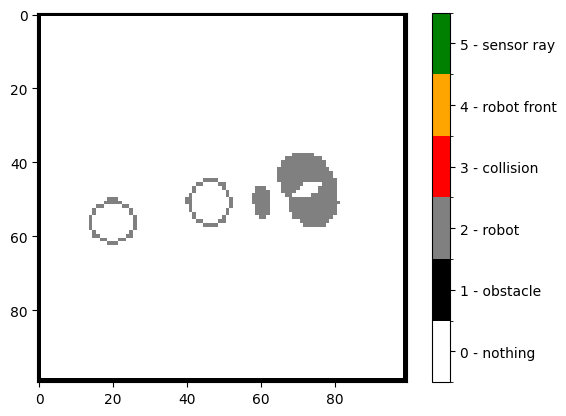

Grid occupancy per robot:
  Robot #1 captured 37 cells
  Robot #2 captured 36 cells
  Robot #3 captured 36 cells
  Robot #4 captured 228 cells


In [6]:
# policy function

class Robot_ANN(Robot):

  weights = []

  def __init__(self, x_0, y_0, theta_0, weights):
    self.weights = weights[:]
    super().__init__(x_0, y_0, theta_0)

  def step(self,sensors):
    translation = self.weights[0]*sensors[-2] + self.weights[1]*sensors[0] + self.weights[2]*sensors[2] + self.weights[3]*sensors[4] + self.weights[4]
    rotation = self.weights[5]*sensors[-2] + self.weights[6]*sensors[0] + self.weights[7]*sensors[2] + self.weights[8]*sensors[4] + self.weights[9]
    #print (sensors,translation,rotation,absolute_orientation)
    return translation,rotation

# Main

init()

print ("#\n# Multi-robots - random search on ANN controller\n#")

display_arena=False # diplay step-by-step if True.
verbose_minimal_progress = True # suggested: True -- useful. Tune gap_between_... to limit the nb of messages

#clear_arena()
create_arena_walls()

nb_robots = 4
robots = []

for i in range(nb_robots):
  robots.append( Robot_ANN( 20+i*20, arena_size//2, 90*i%360, np.random.uniform(-1.0, 1.0, size=10).tolist() ) )
  print ("Robot no.",robots[-1].id,"is alive")

nb_runs = 10
max_iterations = 1001 # 501 may be enough (if computer is slow)

for i in range(nb_runs):
  print ("run no.",(i+1),"of",nb_runs)
  weights = np.random.uniform(-1.0, 1.0, size=10).tolist()
  for j in range(nb_robots):
    robots[j].reset() # reset position and orientation
    robots[j].weights = np.random.uniform(-1.0, 1.0, size=10).tolist()
  retValues = simulate(robots)
  #num_ones = np.count_nonzero(occupancy == 1)
  #print(num_ones)
  print (retValues)
  show_trace()
  # number of cells captured per robot (for each "cell", only the last visitor is registered)
  print("Grid occupancy per robot:")
  robot_ids, visited_cells = np.unique(occupancy, return_counts=True)
  for value, count in zip(robot_ids, visited_cells):
    if value != 0:
      print(f"  Robot #{value} captured {count} cells")


---
---
---

#<font color="orange">Partie 2. Sujet</font>

Nous souhaitons optimiser le comportement de 4 robots pour une tâche de couverture de l'environnement. Du point de vue du groupe, il s'agit de couvrir le maximum de cases (ou cellule) de l'environnement, ce qui correspond ici aux pixels de l'arène. Du point de vue d'un robot seul, il s'agit de capturer le plus de cases possibles, sachant qu'une case "appartient" au dernier robot l'ayant visitée.

Nous allons comparer plusieurs dispositifs expérimentaux selon que l'on considère (1) un collectif homogène (ie. tous les robots utilisent les mêmes paramètres de contrôle pour leur réseaux de neurones) ou hétérogène (les paramètres sont propres à chacun), et (2) une assignation de la fitness au niveau du groupe ou de l'individu. Le sujet s'inspire des travaux de (Waibel et al. 2009) vus en cours.

Vous pouvez utiliser les concepts et les codes des deux précédents sujets, en particulier (1) les algorithmes (1+1)-ES 1/5e et CMAES, (2) le code pour tracer les courbes de résultats, (3) le code permettant de rejouer une simulation pas à pas (pas forcément utile).

Pour chaque question, vous tracerez sur un graphe l'évolution au cours du temps, en faisant figurer la performance du groupe, et les performances individuelles (ie. 5 courbes). L'axe X devra compter le nombre d'appels à la fonction *simulate* (qui est un meilleur indicateur du budget énergétique consommé). Vous sauvegarderez votre meilleur équipe pour eventuellement l'analyser ultérieurement.

*Un conseil avant de commencer: ce sujet vous demande d'utiliser ce que vous avez vu pendant les cours et TME précédents. Les questions sont de difficultés variables, n'hésitez pas à les faire dans le desordre. Voici une indication de l'ordre de difficulté: Q1,Q4 < Q2 < Q3 << Q5 <<<< Q6. Q6 est optionnelle.*

<font color="orange">Equipe homogène</font>

Dans l'approche homogène, ou "clonale", une équipe est constituée de plusieurs robots partageant les mêmes paramètres de contrôles (ici, les mêmes poids d'un réseau de neurones). Ces paramètres sont optimisés par un algorithme évolutionnaire. Du point de vue de l'algorithme, une solution candidate code donc l'ensemble de l'équipe. La performance est généralement évaluée pour l'ensemble de l'équipe. C'est à dire qu'une simulation donne une seule valeur de performance, ce qui correspond ici à la somme des cases capturées par l'équipe. Nous sommes ici donc un cas **coopératif**.

- **Q1**: Implémentez une approche clonale en utilisant l'algorithme (1+1)-ES et une fitness globale (ie. somme des scores de couverture de chaque robot). A vous de fixer les paramètres et le nombre d'itérations de l'algorithme. Analysez les comportements obtenus et commentez.

<font color="orange">Equipe hétérogène</font>

Dans l'approche hétérogène, l'équipe est composée de robots ayant chacun leurs propres paramètres de contrôle. Dans le dispositif le plus classique, l'évaluation se fait en une seule fois, avec tous les robots, et chaque robot se voit attribuée sa performance. Nous sommes ici dans un cas **compétitif**, même si en pratique la compétition n'est observée que s'il existe des conflits d'intérêt (ex.: compétition pour accéder à une ressource).

- **Q2**: Implémentez une approche hétérogène (ie. les paramètres de chaque robot sont optimisés par un algorithme dédié) en utilisant une fitness individuelle (ie. chaque robot optimise son score de couverture). Vous utiliserez un (1+1)-ES par robot. Tracez les résultats. Analysez les comportements obtenus et commentez.

- **Q3**: Implémentez une approche hétérogène en utilisant la fitness globale, c'est à dire que robot participe à l'optimisation du score de couverture de l'équipe. Tracez les résultats.

<font color="orange">Utilisation avec CMAES</font>

- **Q4**: Reprenez la question Q1 avec CMAES.

- **Q5**: (difficile) Reprenez la question Q2 avec CMAES. On aura donc une instance de CMAES par robot. Réflechissez bien à comment réaliser l'évaluation (si vous proposez un protocole d'évaluation différent, justifiez-le). Comparez et commentez les résultats.

<font color="orange">Question ouverte</font>

- **Q6** (difficile et très optionnelle): modifiez le simulateur pour ajouter un second type de senseurs capable de détecter si le senseur touche un mur ou un robot. Refaite la question Q2 avec (1+1)-ES. L'idée est qu'en permettant aux robots d'identifier leurs compétiteurs, on ouvre la voie à des interactions plus riches (suivi, obstruction, etc.).


# Question 1


1) (1+1)-ES simple (sigma fixe)
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Simple ES - gen 5: best fitness = 1865.00
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Simple ES - gen 10: best fitness = 1865.00
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###


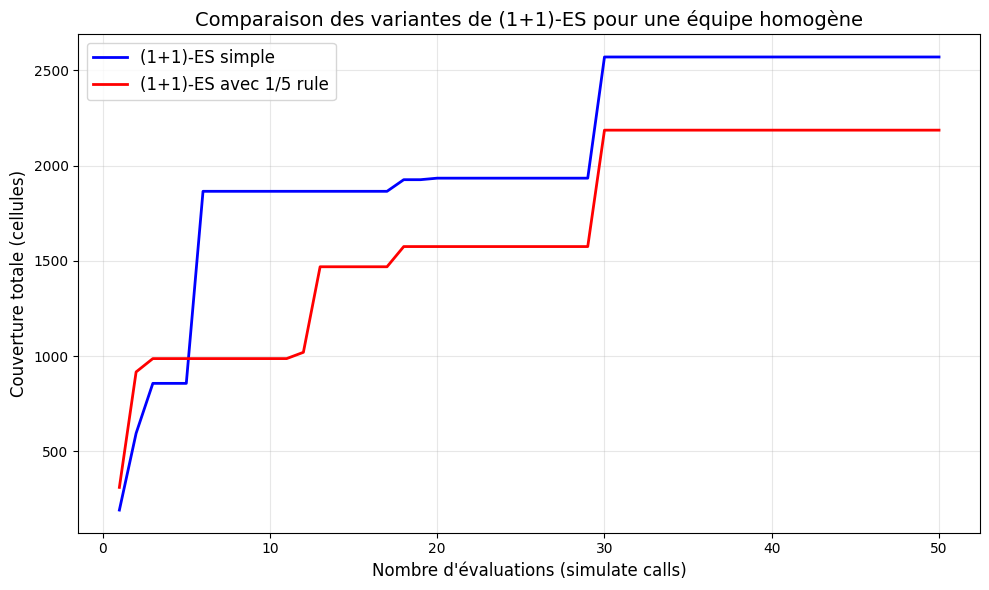


Replay – (1+1)-ES simple (meilleur individu)
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Statistiques : {'translations': 3.9835151087741587, 'rotations': 2.51905557110003, 'coverage': np.float64(0.0637)}
État final :


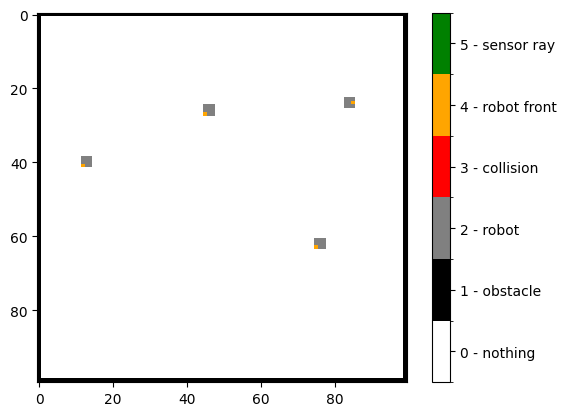

Trajectoires :


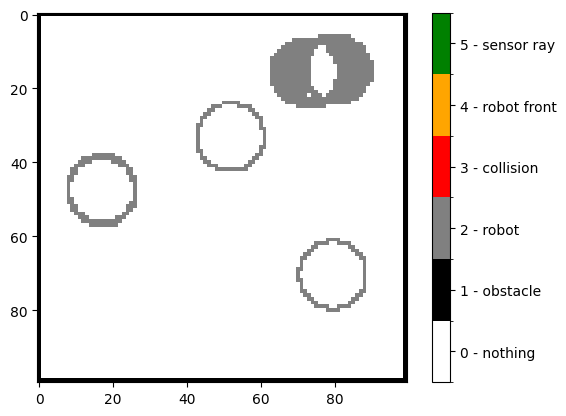


Replay – (1+1)-ES avec règle du 1/5ème (meilleur individu)
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Statistiques : {'translations': 3.9508985035709854, 'rotations': 3.9978806054205784, 'coverage': np.float64(0.074)}
État final :


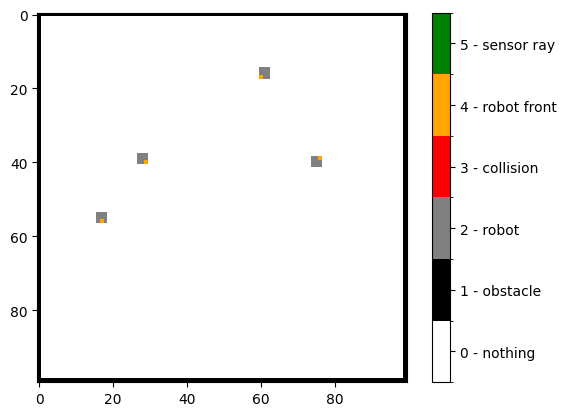

Trajectoires :


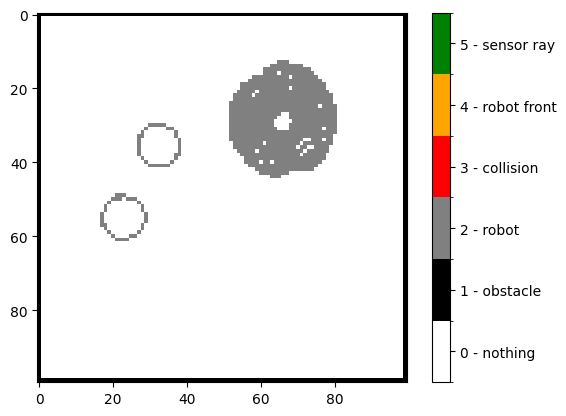


Terminé.


In [7]:
# ============================================================================
# Comparaison de (1+1)-ES simple vs (1+1)-ES avec règle du 1/5ème
# Optimisation d'une équipe homogène (4 robots) pour maximiser la couverture
# ============================================================================

import random
import numpy as np
import matplotlib.pyplot as plt

# -------------------- Paramètres communs --------------------
arena_size = 100
max_iterations = 1001      # nombre de pas de simulation par évaluation
n_robots = 4
n_evaluations = 50        # nombre total d'évaluations (y compris l'initiale)
sigma_init = 0.1           # pas initial

# -------------------- Fonction de fitness (identique pour les deux méthodes) --------------------
def evaluate_team(weights):
    """
    Évalue une équipe homogène (tous les robots utilisent les mêmes poids).
    Retourne le nombre total de cellules couvertes par l'équipe.
    """
    robots = []
    positions = []          # pour stocker (x, y, theta) des robots déjà créés
    max_attempts = 100

    for i in range(n_robots):
        for attempt in range(max_attempts):
            x = random.randint(particle_box, arena_size - particle_box - 1)
            y = random.randint(particle_box, arena_size - particle_box - 1)
            theta = random.uniform(-180, 180)

            collision = False
            for (px, py, _) in positions:
                if abs(x - px) < particle_box and abs(y - py) < particle_box:
                    collision = True
                    break

            if not collision:
                positions.append((x, y, theta))
                break
        else:
            x = random.randint(particle_box, arena_size - particle_box - 1)
            y = random.randint(particle_box, arena_size - particle_box - 1)
            theta = random.uniform(-180, 180)
            positions.append((x, y, theta))

    for (x, y, theta) in positions:
        robots.append(Robot_ANN(x, y, theta, weights))

    ret = simulate(robots)
    team_coverage = ret['coverage'] * (arena_size ** 2)
    return team_coverage

# -------------------- Version 1 : (1+1)-ES simple (sans adaptation de sigma) --------------------
def run_simple_es():
    """Exécute (1+1)-ES avec sigma fixe."""
    best = np.random.uniform(-1, 1, size=10).tolist()
    best_fitness = evaluate_team(best)
    eval_count = 1
    best_fitness_history = [best_fitness]
    eval_counts_history = [eval_count]

    for gen in range(1, n_evaluations):
        child = [w + np.random.normal(0, sigma_init) for w in best]
        child = np.clip(child, -1, 1).tolist()
        child_fitness = evaluate_team(child)
        eval_count += 1

        if child_fitness >= best_fitness:
            best = child
            best_fitness = child_fitness

        best_fitness_history.append(best_fitness)
        eval_counts_history.append(eval_count)

        if gen % (n_evaluations // 10) == 0:
            print(f"Simple ES - gen {gen}: best fitness = {best_fitness:.2f}")

    return best, best_fitness, eval_counts_history, best_fitness_history

# -------------------- Version 2 : (1+1)-ES avec règle du 1/5ème --------------------
def run_adaptive_es():
    """Exécute (1+1)-ES avec règle du 1/5ème pour adapter sigma."""
    x = np.array(np.random.uniform(-1, 1, size=10), dtype=float)
    best_fit = evaluate_team(x.tolist())
    best_x = x.copy()
    sigma = sigma_init
    data = [best_fit]
    eval_counts = [1]

    for i in range(1, n_evaluations):
        x_prime = x + sigma * np.random.randn(*x.shape)
        fit_prime = evaluate_team(x_prime.tolist())

        if fit_prime >= best_fit:
            x = x_prime
            best_fit = fit_prime
            best_x = x.copy()
            sigma = min(sigma * 2, 2.0)          # succès : augmenter sigma
        else:
            sigma = max(sigma * (2 ** (-0.25)), 1e-10)  # échec : réduire sigma

        data.append(best_fit)
        eval_counts.append(i + 1)

        if i % (n_evaluations // 10) == 0:
            print(f"Adaptive ES - it {i}: best_fit = {best_fit:.2f}, sigma = {sigma:.4f}")

    return best_x.tolist(), best_fit, eval_counts, data

# -------------------- Initialisation de l'environnement (commune) --------------------
init()
create_arena_walls()
# create_wall_1()   # facultatif

# -------------------- Exécution des deux algorithmes --------------------
print("\n" + "="*60)
print("1) (1+1)-ES simple (sigma fixe)")
print("="*60)
best_simple, fit_simple, evals_simple, hist_simple = run_simple_es()

print("\n" + "="*60)
print("2) (1+1)-ES avec règle du 1/5ème")
print("="*60)
best_adapt, fit_adapt, evals_adapt, hist_adapt = run_adaptive_es()

# ==================== AFFICHAGE DES MEILLEURS PARAMÈTRES ====================
print("\n" + "="*60)
print("Résultats finaux des deux algorithmes")
print("="*60)
print("\n--- (1+1)-ES simple ---")
print(f"Meilleure couverture totale : {fit_simple:.2f}")
print(f"Poids optimaux : {best_simple}")

print("\n--- (1+1)-ES avec règle du 1/5ème ---")
print(f"Meilleure couverture totale : {fit_adapt:.2f}")
print(f"Poids optimaux : {best_adapt}")

# -------------------- Tracé comparatif des courbes d'apprentissage --------------------
plt.figure(figsize=(10,6))
plt.plot(evals_simple, hist_simple, 'b-', linewidth=2, label='(1+1)-ES simple')
plt.plot(evals_adapt, hist_adapt, 'r-', linewidth=2, label='(1+1)-ES avec 1/5 rule')
plt.xlabel("Nombre d'évaluations (simulate calls)", fontsize=12)
plt.ylabel("Couverture totale (cellules)", fontsize=12)
plt.title("Comparaison des variantes de (1+1)-ES pour une équipe homogène", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------- Replay du meilleur individu de chaque méthode --------------------
def replay_best(weights, title):
    print("\n" + "="*60)
    print(title)
    print("="*60)
    robots = []
    for i in range(n_robots):
        x = random.randint(particle_box, arena_size - particle_box - 1)
        y = random.randint(particle_box, arena_size - particle_box - 1)
        theta = random.uniform(-180, 180)
        robots.append(Robot_ANN(x, y, theta, weights))
    ret = simulate(robots)
    print("Statistiques :", ret)
    print("État final :")
    show_arena()
    print("Trajectoires :")
    show_trace()

replay_best(best_simple, "Replay – (1+1)-ES simple (meilleur individu)")
replay_best(best_adapt, "Replay – (1+1)-ES avec règle du 1/5ème (meilleur individu)")

print("\nTerminé.")

# Question 2

### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Initial team coverage: 1076.00
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###


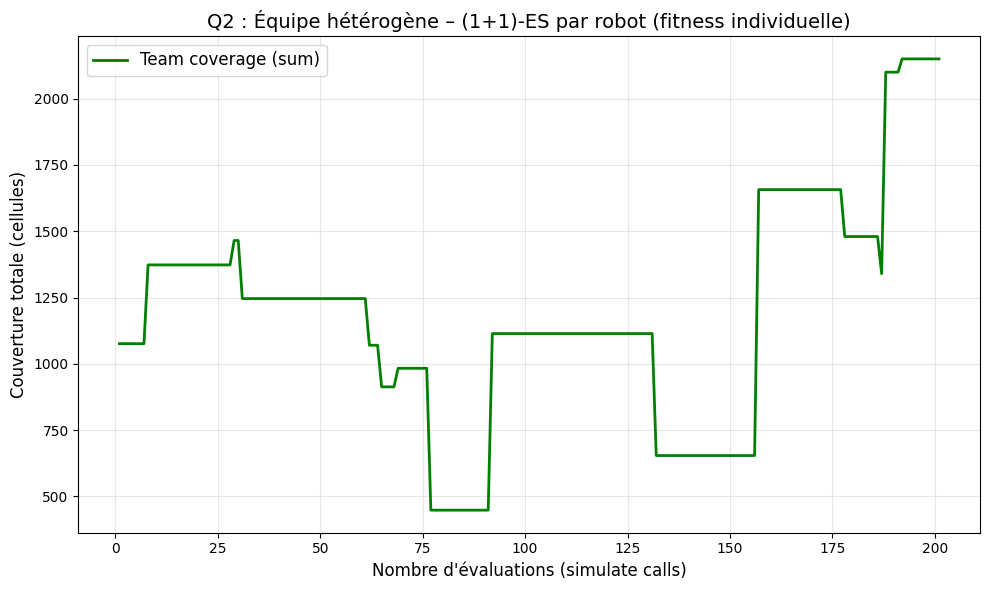

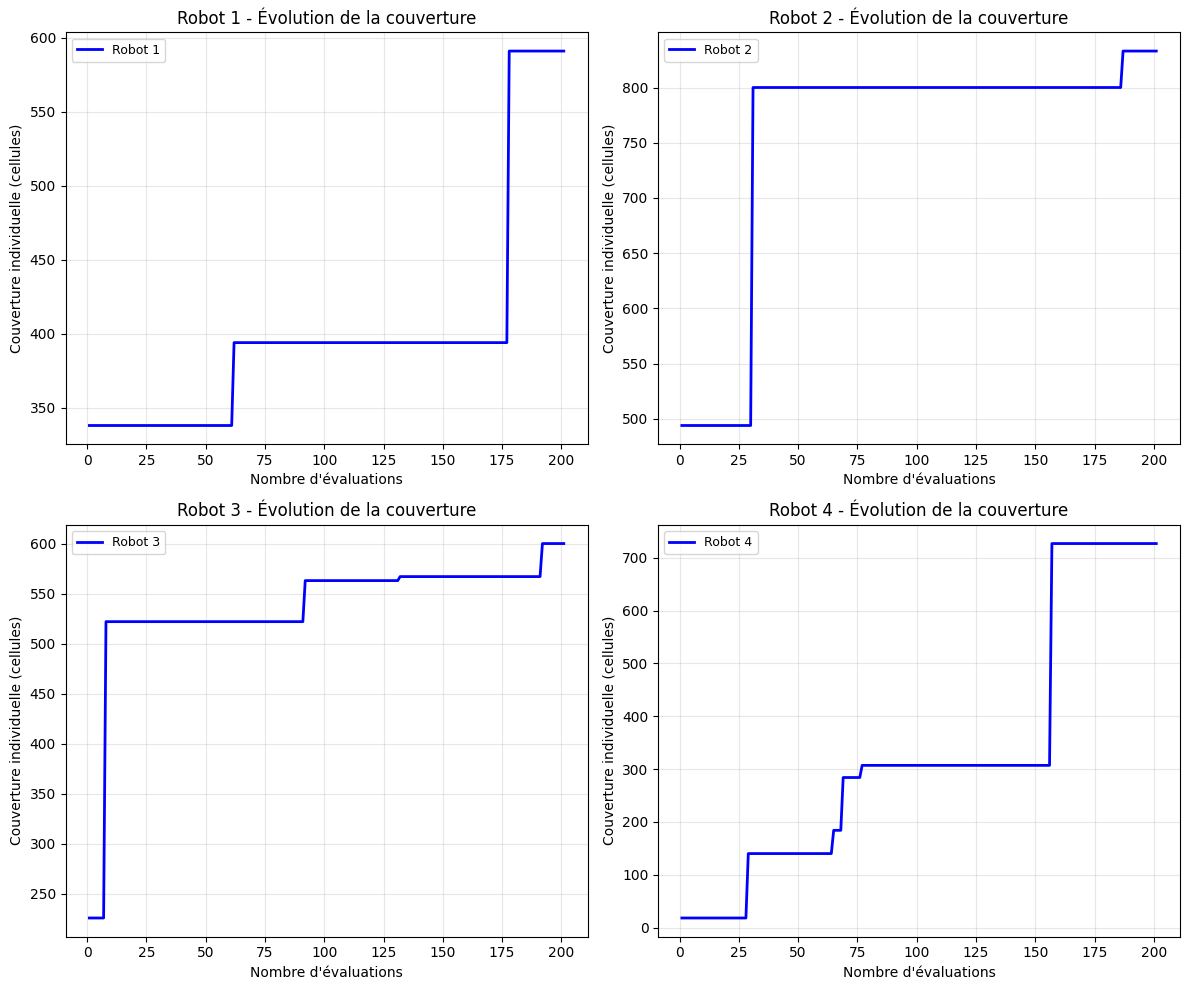


=== Meilleurs paramètres (poids) obtenus ===
Meilleure couverture totale finale : 2150.00
Robot 1 : [0.19966084219725944, 0.5472150568734881, -0.31433271031067594, 0.7858637507749374, -0.10102720677106206, 0.4803547820385866, -0.26197965477766555, -0.6625605263400062, 0.478471337582021, -0.41813503031326826]
Robot 2 : [-0.6646103408836712, 0.40952720479197385, -0.7364589984147654, -0.8531847471601132, -0.7437243650174268, -0.5316170907255481, -0.4055551677275807, -0.16282994499663414, 0.7753941705676086, -0.3369253393334389]
Robot 3 : [0.4856136449346542, 0.30541399369826916, 0.10503057220010967, -0.030529759167885473, 0.0007612946398972836, 0.4283122819817803, 0.34066781693929515, 1.0, -0.5133126220518051, 0.7971452981385608]
Robot 4 : [-0.5882389628930199, 0.2825595365251413, -0.9899343243502414, 0.48707449688153925, -0.11221806747754615, -0.9667790447707534, 0.9589747309280311, -0.15459229789264903, 0.195262076341233, 0.7538843122373087]


Replay de l'équipe optimisée (positions al

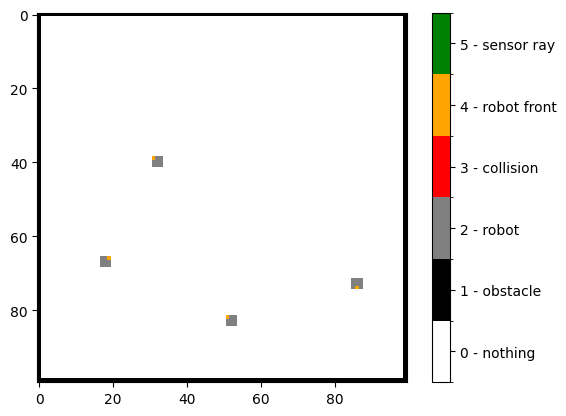

Trajectoires :


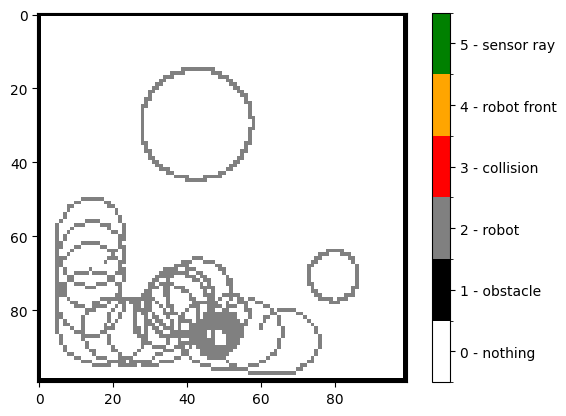


Terminé.


In [8]:
# ============================================================================
# Q2 : Équipe hétérogène – (1+1)-ES par robot, fitness individuelle
# Chaque robot optimise son propre score de couverture.
# ============================================================================

import random
import numpy as np
import matplotlib.pyplot as plt

# -------------------- Paramètres --------------------
arena_size = 100
max_iterations = 1001          # nombre de pas de simulation par évaluation
n_robots = 4
n_updates_per_robot = 50       # nombre de mises à jour (évaluations) par robot
sigma = 0.1                    # pas de mutation fixe

# -------------------- Évaluation d'une équipe hétérogène --------------------
def evaluate_heterogeneous_team(weights_list):
    """
    Évalue une équipe où chaque robot a ses propres poids.
    Retourne : liste des couvertures individuelles, couverture totale de l'équipe.
    """
    # réinitialisation complète de l'environnement
    init()                     # réinitialise toutes les structures globales (occupancy, etc.)
    create_arena_walls()       # recrée les murs
    # ===============================================================================

    robots = []
    positions = []
    max_attempts = 100

    for i in range(n_robots):
        for _ in range(max_attempts):
            x = random.randint(particle_box, arena_size - particle_box - 1)
            y = random.randint(particle_box, arena_size - particle_box - 1)
            theta = random.uniform(-180, 180)

            collision = False
            for (px, py, _) in positions:
                if abs(x - px) < particle_box and abs(y - py) < particle_box:
                    collision = True
                    break

            if not collision:
                positions.append((x, y, theta))
                break
        else:
            x = random.randint(particle_box, arena_size - particle_box - 1)
            y = random.randint(particle_box, arena_size - particle_box - 1)
            theta = random.uniform(-180, 180)
            positions.append((x, y, theta))

    for i in range(n_robots):
        robots.append(Robot_ANN(positions[i][0], positions[i][1], positions[i][2], weights_list[i]))

    ret = simulate(robots)
    # Récupération des couvertures individuelles depuis la matrice d'occupation
    individual_counts = [np.sum(occupancy == (i+1)) for i in range(n_robots)]
    total_coverage = sum(individual_counts)
    return individual_counts, total_coverage

# -------------------- Initialisation de l'environnement --------------------
init()
create_arena_walls()
# create_wall_1()   # facultatif

# -------------------- Initialisation des robots --------------------
# Chaque robot a 10 poids
current_weights = [np.random.uniform(-1, 1, size=10).tolist() for _ in range(n_robots)]
best_weights = [w[:] for w in current_weights]          # meilleurs poids de chaque robot
best_ind_fitness = [0.0] * n_robots                     # meilleure couverture individuelle de chaque robot

# Historique pour le tracé
total_coverage_history = []
eval_counts_history = []
eval_count = 0

# historique des couvertures individuelles
individual_fitness_history = [[] for _ in range(n_robots)]   # chaque robot aura sa liste

# Évaluation initiale (pour initialiser les meilleurs)
ind_fit, total_fit = evaluate_heterogeneous_team(current_weights)
eval_count += 1
for i in range(n_robots):
    best_ind_fitness[i] = ind_fit[i]

# conserver la couverture individuelle courante
current_ind_fitness = ind_fit.copy()   # liste des couvertures individuelles de l'équipe courante

# on conserve la couverture totale de l'équipe courante
current_total_fitness = total_fit   # variable pour suivre la couverture de l'équipe courante
total_coverage_history.append(current_total_fitness)
eval_counts_history.append(eval_count)

# enregistrer les couvertures individuelles initiales
for i in range(n_robots):
    individual_fitness_history[i].append(current_ind_fitness[i])

print(f"Initial team coverage: {current_total_fitness:.2f}")

# -------------------- Optimisation séquentielle par robot --------------------
# On effectue un nombre fixe de mises à jour par robot (on alterne)
total_updates = n_robots * n_updates_per_robot
update_count = 0

while update_count < total_updates:
    robot_idx = update_count % n_robots   # parcours circulaire des robots

    # Générer un enfant pour ce robot (mutation)
    child_weights = [w[:] for w in current_weights]   # copie
    child_weights[robot_idx] = [w + np.random.normal(0, sigma) for w in current_weights[robot_idx]]
    child_weights[robot_idx] = np.clip(child_weights[robot_idx], -1, 1).tolist()

    # Évaluer l'équipe avec ce nouveau poids pour le robot concerné
    ind_fit, total_fit = evaluate_heterogeneous_team(child_weights)
    eval_count += 1

    # Sélection (1+1) – accepte si la couverture du robot s'améliore
    if ind_fit[robot_idx] >= best_ind_fitness[robot_idx]:
        current_weights[robot_idx] = child_weights[robot_idx]
        best_weights[robot_idx] = child_weights[robot_idx]
        best_ind_fitness[robot_idx] = ind_fit[robot_idx]
        # mettre à jour la couverture courante
        current_total_fitness = total_fit   # on accepte la couverture de l'enfant
        # mettre à jour la couverture individuelle courante
        current_ind_fitness[robot_idx] = ind_fit[robot_idx]   # pour le robot modifié
    # else: rejet, current_total_fitness et current_ind_fitness restent inchangés

    # enregistrer la couverture de l'équipe courante
    total_coverage_history.append(current_total_fitness)
    eval_counts_history.append(eval_count)

    # enregistrer les couvertures individuelles courantes
    for i in range(n_robots):
        individual_fitness_history[i].append(current_ind_fitness[i])

    update_count += 1
    if update_count % (n_robots * (n_updates_per_robot // 10)) == 0 and n_updates_per_robot // 10 > 0:
        print(f"Updates done: {update_count}/{total_updates} – current team coverage: {current_total_fitness:.2f}")

# -------------------- Tracé de l'évolution de la couverture totale --------------------
plt.figure(figsize=(10,6))
plt.plot(eval_counts_history, total_coverage_history, 'g-', linewidth=2, label='Team coverage (sum)')
plt.xlabel("Nombre d'évaluations (simulate calls)", fontsize=12)
plt.ylabel("Couverture totale (cellules)", fontsize=12)
plt.title("Q2 : Équipe hétérogène – (1+1)-ES par robot (fitness individuelle)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==================== Tracé des couvertures individuelles ====================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))   # 2x2 pour 4 robots
axes = axes.flatten()

for i in range(n_robots):
    ax = axes[i]
    ax.plot(eval_counts_history, individual_fitness_history[i], 'b-', linewidth=2, label=f'Robot {i+1}')
    ax.set_xlabel("Nombre d'évaluations", fontsize=10)
    ax.set_ylabel("Couverture individuelle (cellules)", fontsize=10)
    ax.set_title(f"Robot {i+1} - Évolution de la couverture", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ==================== AFFICHAGE DES MEILLEURS PARAMÈTRES ====================
print("\n=== Meilleurs paramètres (poids) obtenus ===")
print(f"Meilleure couverture totale finale : {current_total_fitness:.2f}")
for i in range(n_robots):
    print(f"Robot {i+1} : {best_weights[i]}")
print("===========================================\n")

# -------------------- Replay du meilleur individu de chaque robot --------------------
print("\nReplay de l'équipe optimisée (positions aléatoires) :")
robots = []
for i in range(n_robots):
    x = random.randint(particle_box, arena_size - particle_box - 1)
    y = random.randint(particle_box, arena_size - particle_box - 1)
    theta = random.uniform(-180, 180)
    robots.append(Robot_ANN(x, y, theta, best_weights[i]))

ret = simulate(robots)
print("Statistiques finales :", ret)
print("État final :")
show_arena()
print("Trajectoires :")
show_trace()

print("\nTerminé.")

# Question 3


# (1+1)-ES simple pour équipe hétérogène – fitness globale (couverture totale) #

### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
it =     5, current_fit = 165.00, best_fit = 802.00, sigma = 0.1000
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
it =    10, current_fit = 444.00, best_fit = 802.00, sigma = 0.1000
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration

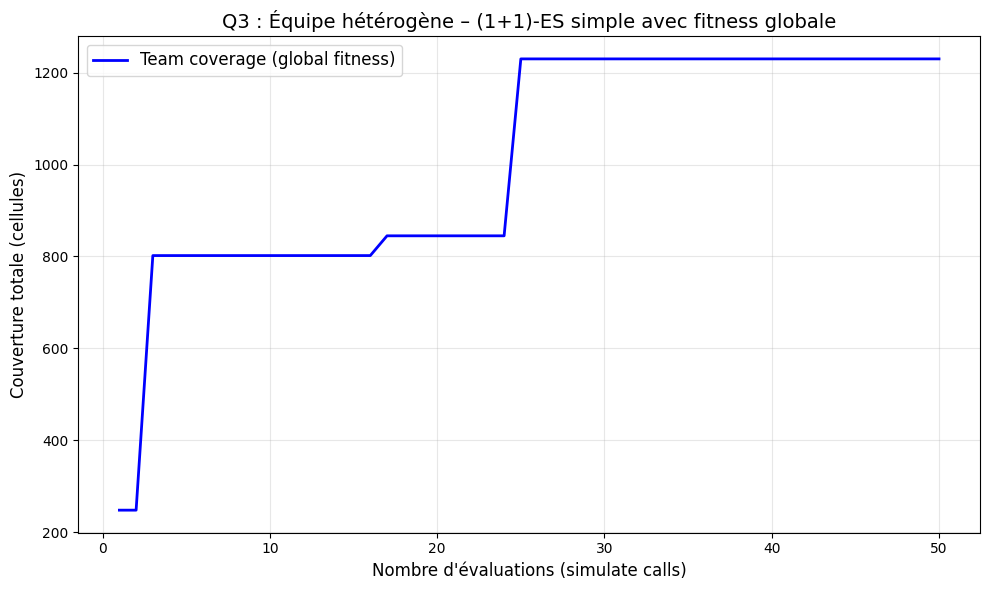

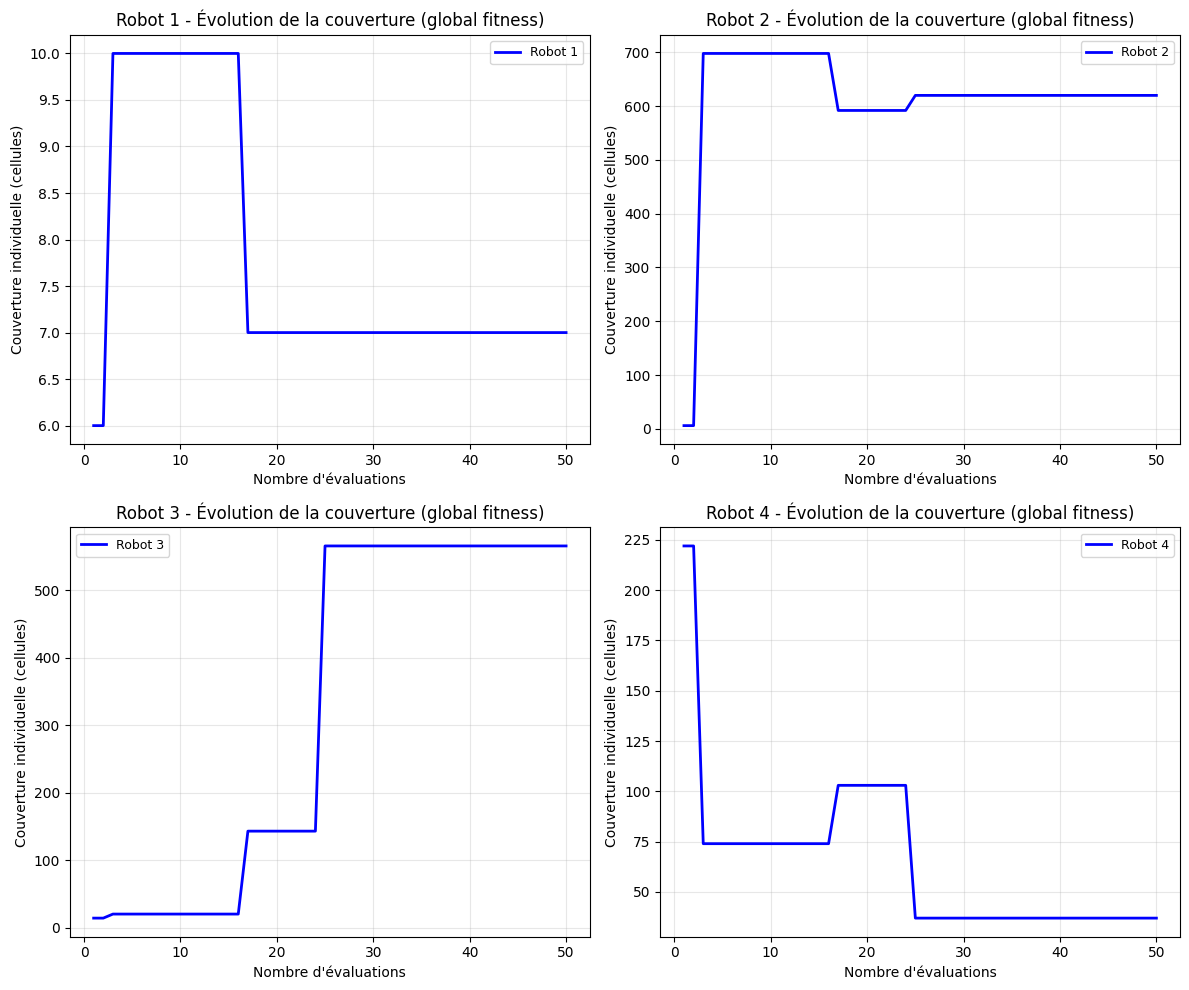


Replay de l'équipe optimisée (positions aléatoires) :
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Statistiques finales : {'translations': 1.1096225628206606, 'rotations': 1.8009707404872128, 'coverage': np.float64(0.0696)}
État final :


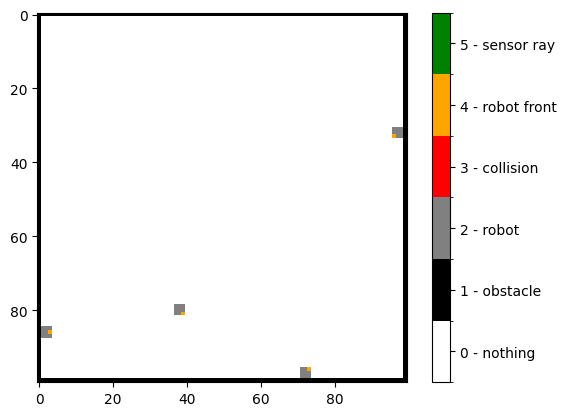

Trajectoires :


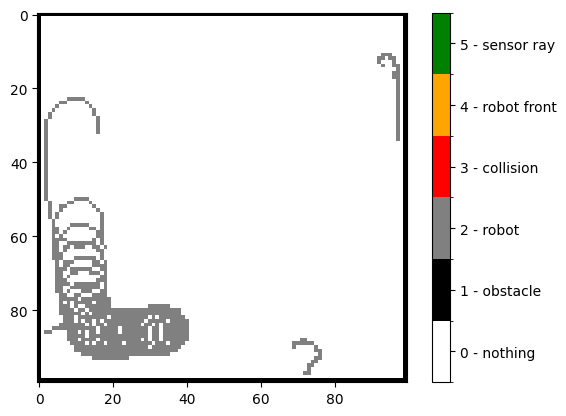


Terminé.


In [9]:
# ============================================================================
# Q3 : Équipe hétérogène – (1+1)-ES simple avec fitness globale
# Tous les robots participent à l'optimisation du score de couverture de l'équipe.
# ============================================================================

import random
import numpy as np
import matplotlib.pyplot as plt

# -------------------- Paramètres --------------------
arena_size = 100
max_iterations = 1001          # nombre de pas de simulation par évaluation
n_robots = 4
n_evaluations = 50            # nombre total d'évaluations (y compris l'initiale)
sigma = 0.1                    # pas de mutation fixe (pas d'adaptation)

# -------------------- Évaluation d'une équipe hétérogène (fitness globale) --------------------
def evaluate_heterogeneous_team_global(flat_weights):
    """
    Évalue une équipe hétérogène à partir d'un vecteur de poids aplati (dim = n_robots * 10).
    Retourne la couverture totale de l'équipe et les couvertures individuelles.
    """
    # Réinitialisation de l'environnement
    init()
    create_arena_walls()

    # Découpage du vecteur plat en 4 listes de 10 poids
    weights_list = []
    for i in range(n_robots):
        start = i * 10
        end = (i+1) * 10
        weights_list.append(flat_weights[start:end].tolist())

    # Génération des positions aléatoires sans chevauchement
    robots = []
    positions = []
    max_attempts = 100

    for i in range(n_robots):
        placed = False
        for _ in range(max_attempts):
            x = random.randint(particle_box, arena_size - particle_box - 1)
            y = random.randint(particle_box, arena_size - particle_box - 1)
            theta = random.uniform(-180, 180)

            collision = False
            for (px, py, _) in positions:
                if abs(x - px) < particle_box and abs(y - py) < particle_box:
                    collision = True
                    break

            if not collision:
                positions.append((x, y, theta))
                placed = True
                break
        if not placed:
            print(f"Warning: Could not place robot {i} after {max_attempts} attempts.")
            x = random.randint(particle_box, arena_size - particle_box - 1)
            y = random.randint(particle_box, arena_size - particle_box - 1)
            theta = random.uniform(-180, 180)
            positions.append((x, y, theta))

    for i in range(n_robots):
        robots.append(Robot_ANN(positions[i][0], positions[i][1], positions[i][2], weights_list[i]))

    ret = simulate(robots)
    total_coverage = ret['coverage'] * (arena_size ** 2)
    # Récupération des couvertures individuelles depuis la matrice d'occupation
    individual_counts = [np.sum(occupancy == (i+1)) for i in range(n_robots)]
    return total_coverage, individual_counts

# -------------------- (1+1)-ES simple pour le vecteur complet --------------------
def run_oneplusone_global_simple(initial, sigma, n_eval, display, fitness_func):
    """
    (1+1)-ES simple avec sigma fixe pour un vecteur de paramètres global (40 dimensions).
    initial : solution initiale (list ou array)
    sigma   : pas de mutation fixe
    n_eval  : nombre total d'évaluations (y compris initiale)
    display : booléen pour afficher la progression
    fitness_func : fonction à maximiser, doit retourner (total_fitness, individual_list)
    Returns: meilleure solution, meilleure fitness, historiques (eval_counts, best_fitness, individual_histories)
    """
    x = np.array(initial, dtype=float)
    best_fit, best_ind = fitness_func(x)
    best_x = x.copy()
    best_ind_fit = best_ind.copy()  # meilleures couvertures individuelles associées

    eval_counts = [1]
    best_fitness_history = [best_fit]
    # Historique des couvertures individuelles pour chaque robot
    individual_histories = [[] for _ in range(n_robots)]
    for i in range(n_robots):
        individual_histories[i].append(best_ind[i])

    for i in range(1, n_eval):
        # Mutation : ajout d'un bruit gaussien de même écart-type sigma
        x_prime = x + sigma * np.random.randn(*x.shape)
        fit_prime, ind_prime = fitness_func(x_prime)

        # Sélection : on accepte si la fitness ne diminue pas (>=)
        if fit_prime >= best_fit:
            x = x_prime
            best_fit = fit_prime
            best_x = x.copy()
            best_ind_fit = ind_prime.copy()

        eval_counts.append(i+1)
        best_fitness_history.append(best_fit)
        # Enregistrer les couvertures individuelles actuelles (celles associées au meilleur total)
        for j in range(n_robots):
            individual_histories[j].append(best_ind_fit[j])

        if display and i % max(1, n_eval // 10) == 0:
            print(f"it = {i:5d}, current_fit = {fit_prime:.2f}, best_fit = {best_fit:.2f}, sigma = {sigma:.4f}")

    return best_x.tolist(), best_fit, eval_counts, best_fitness_history, individual_histories

# -------------------- Initialisation de l'environnement --------------------
init()
create_arena_walls()
# create_wall_1()   # facultatif

# -------------------- Optimisation --------------------
dim = n_robots * 10
initial_solution = np.random.uniform(-1, 1, size=dim).tolist()

print("\n# (1+1)-ES simple pour équipe hétérogène – fitness globale (couverture totale) #\n")
best_solution, best_fitness, eval_counts, best_fitness_history, individual_histories = run_oneplusone_global_simple(
    initial=initial_solution,
    sigma=sigma,
    n_eval=n_evaluations,
    display=True,
    fitness_func=evaluate_heterogeneous_team_global
)

print(f"\nMeilleure couverture totale obtenue : {best_fitness:.2f}")

# ==================== Affichage des meilleurs paramètres ====================
print("\n=== Meilleurs paramètres (poids) obtenus ===")
print("Vecteur plat (40 dimensions) :")
print(best_solution)

print("\nPoids par robot :")
for i in range(n_robots):
    start = i * 10
    end = (i+1) * 10
    print(f"Robot {i+1} : {best_solution[start:end]}")
print("===========================================\n")

# -------------------- Tracé de l'évolution de la couverture totale --------------------
plt.figure(figsize=(10,6))
plt.plot(eval_counts, best_fitness_history, 'b-', linewidth=2, label='Team coverage (global fitness)')
plt.xlabel("Nombre d'évaluations (simulate calls)", fontsize=12)
plt.ylabel("Couverture totale (cellules)", fontsize=12)
plt.title("Q3 : Équipe hétérogène – (1+1)-ES simple avec fitness globale", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==================== Tracé des couvertures individuelles ====================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))   # 2x2 pour 4 robots
axes = axes.flatten()

for i in range(n_robots):
    ax = axes[i]
    ax.plot(eval_counts, individual_histories[i], 'b-', linewidth=2, label=f'Robot {i+1}')
    ax.set_xlabel("Nombre d'évaluations", fontsize=10)
    ax.set_ylabel("Couverture individuelle (cellules)", fontsize=10)
    ax.set_title(f"Robot {i+1} - Évolution de la couverture (global fitness)", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# -------------------- Replay du meilleur individu --------------------
print("\nReplay de l'équipe optimisée (positions aléatoires) :")
# Découpage du vecteur plat
best_weights_list = []
for i in range(n_robots):
    start = i * 10
    end = (i+1) * 10
    best_weights_list.append(best_solution[start:end])

robots = []
for i in range(n_robots):
    x = random.randint(particle_box, arena_size - particle_box - 1)
    y = random.randint(particle_box, arena_size - particle_box - 1)
    theta = random.uniform(-180, 180)
    robots.append(Robot_ANN(x, y, theta, best_weights_list[i]))

ret = simulate(robots)
print("Statistiques finales :", ret)
print("État final :")
show_arena()
print("Trajectoires :")
show_trace()

print("\nTerminé.")

# Question 4


# Optimisation d'une équipe homogène avec CMA-ES (fitness globale) #

(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimension 10 (seed=648004, Thu Mar 26 17:27:11 2026)
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Eval 0: coverage = 1102.00
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Eval 0: coverage = 863.00
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Eval 0: coverage = 1946.00
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Eval 0: coverage = 582.00
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Eval 0: coverage = 975.00
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Eval 0: coverage = 2138.00
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Eval 0: coverage = 138.00
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Eval 0: coverage = 142.00
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Eval 0: coverage = 368.00
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Eval 0: coverage = 166.00
Iter

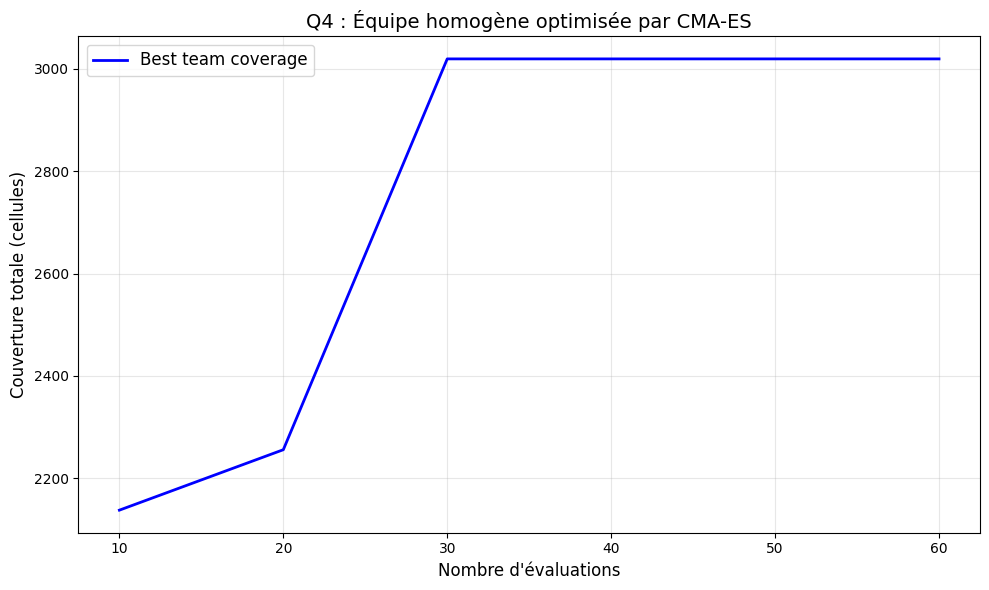


Replay de la meilleure équipe (positions aléatoires) :
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Statistiques finales : {'translations': 3.8583509484847953, 'rotations': 0.9631153474694094, 'coverage': np.float64(0.2929)}
État final :


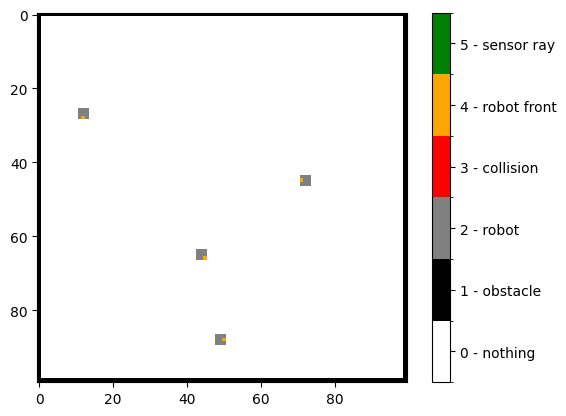

Trajectoires :


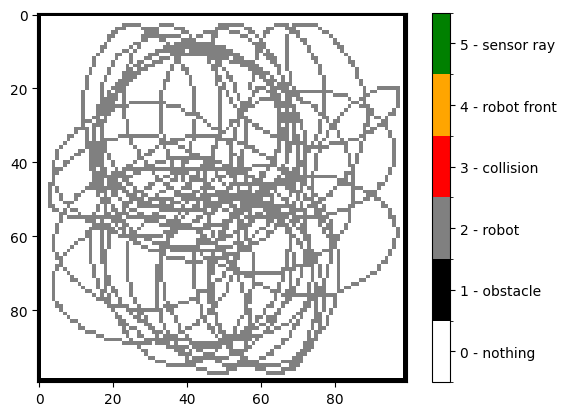


Terminé.


In [10]:
# ============================================================================
# Q4 : Équipe homogène avec CMA-ES (fitness globale)
# ============================================================================

# -------------------- Paramètres --------------------
arena_size = 100
max_iterations = 1001          # nombre de pas de simulation par évaluation
n_robots = 4
max_evaluations = 50          # budget total d'évaluations pour CMA-ES

# -------------------- Fonction de fitness : couverture totale de l'équipe --------------------
def evaluate_team_coverage(weights):
    """
    Évalue une équipe homogène (tous les robots partagent les mêmes poids).
    Retourne le nombre total de cellules couvertes par l'équipe.
    """
    # Réinitialisation de l'environnement à chaque évaluation
    init()
    create_arena_walls()

    # Génération des positions initiales sans chevauchement
    robots = []
    positions = []
    max_attempts = 100

    for i in range(n_robots):
        placed = False
        for _ in range(max_attempts):
            x = random.randint(particle_box, arena_size - particle_box - 1)
            y = random.randint(particle_box, arena_size - particle_box - 1)
            theta = random.uniform(-180, 180)

            collision = False
            for (px, py, _) in positions:
                if abs(x - px) < particle_box and abs(y - py) < particle_box:
                    collision = True
                    break

            if not collision:
                positions.append((x, y, theta))
                placed = True
                break
        if not placed:
            print(f"Warning: Could not place robot {i} after {max_attempts} attempts.")
            x = random.randint(particle_box, arena_size - particle_box - 1)
            y = random.randint(particle_box, arena_size - particle_box - 1)
            theta = random.uniform(-180, 180)
            positions.append((x, y, theta))

    # Création des robots avec les mêmes poids
    for i in range(n_robots):
        robots.append(Robot_ANN(positions[i][0], positions[i][1], positions[i][2], weights))

    # Simulation
    ret = simulate(robots)
    total_coverage = ret['coverage'] * (arena_size ** 2)
    return total_coverage

# -------------------- Lancement de CMA-ES --------------------
def launch_cmaes_team(dim, max_evaluations, display=False):
    """
    Lance CMA-ES pour optimiser les poids d'une équipe homogène.
    Retourne : meilleure fitness, meilleurs paramètres, historique (évaluations, fitness)
    """
    # Point de départ aléatoire
    x0 = np.random.uniform(-1, 1, dim)

    # Stratégie CMA-ES
    es = cma.CMAEvolutionStrategy(x0, 0.5)

    # Configuration des options
    es.opts.set({
        'maxfevals': max_evaluations,
        'verbose': -1 if not display else 1,
        'verb_disp': max(1, max_evaluations // 10),
        'tolfun': 0,
        'tolx': 0,
        'tolconditioncov': 0,
    })

    # Historique
    eval_counts = []
    best_fitness_history = []   # meilleure fitness (maximisée) à chaque étape

    # Fonction objectif (minimisation)
    def objective(params):
        coverage = evaluate_team_coverage(params.tolist())
        # Afficher la progression (optionnel)
        if len(eval_counts) % (max_evaluations // 10) == 0:
            print(f"Eval {len(eval_counts)}: coverage = {coverage:.2f}")
        return -coverage   # CMA-ES minimise

    # Callback pour enregistrer la meilleure solution
    def callback(es):
        eval_counts.append(es.countevals)
        best_fitness_history.append(-es.best.f)   # convertir en maximisation

    es.optimize(objective, callback=callback)

    best_fitness = -es.result.fbest
    best_params = es.result.xbest.tolist()

    return best_fitness, best_params, eval_counts, best_fitness_history

# -------------------- Exécution --------------------
print("\n# Optimisation d'une équipe homogène avec CMA-ES (fitness globale) #\n")

init()                         # initialisation des structures globales
create_arena_walls()           # murs de l'arène

best_fitness, best_params, evals, fitness_history = launch_cmaes_team(
    dim=10,
    max_evaluations=max_evaluations,
    display=True
)

print(f"\nMeilleure couverture obtenue : {best_fitness:.2f} cellules")
print("Meilleurs poids :", best_params)

# -------------------- Tracé de l'évolution --------------------
plt.figure(figsize=(10,6))
plt.plot(evals, fitness_history, 'b-', linewidth=2, label='Best team coverage')
plt.xlabel("Nombre d'évaluations", fontsize=12)
plt.ylabel("Couverture totale (cellules)", fontsize=12)
plt.title("Q4 : Équipe homogène optimisée par CMA-ES", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------- Replay du meilleur individu --------------------
print("\nReplay de la meilleure équipe (positions aléatoires) :")
robots = []
for i in range(n_robots):
    x = random.randint(particle_box, arena_size - particle_box - 1)
    y = random.randint(particle_box, arena_size - particle_box - 1)
    theta = random.uniform(-180, 180)
    robots.append(Robot_ANN(x, y, theta, best_params))

ret = simulate(robots)
print("Statistiques finales :", ret)
print("État final :")
show_arena()
print("Trajectoires :")
show_trace()

print("\nTerminé.")

# Question 5

Évaluation initiale...
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Initial team coverage: 270.00

Optimisation avec CMA‑ES par robot (multi‑tours)

--- Tour 1/5 ---
  Optimisation du robot 1...
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001

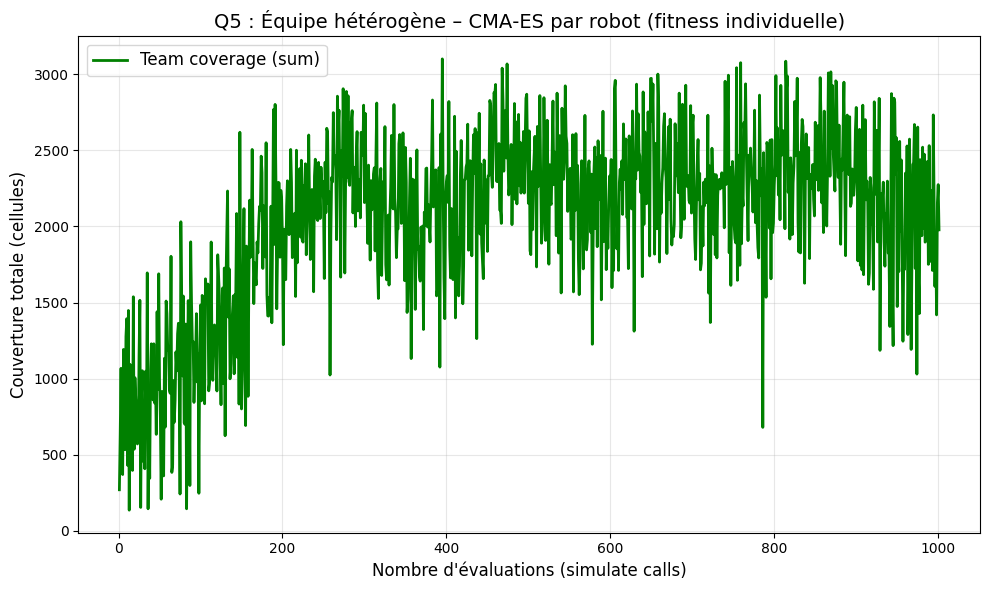

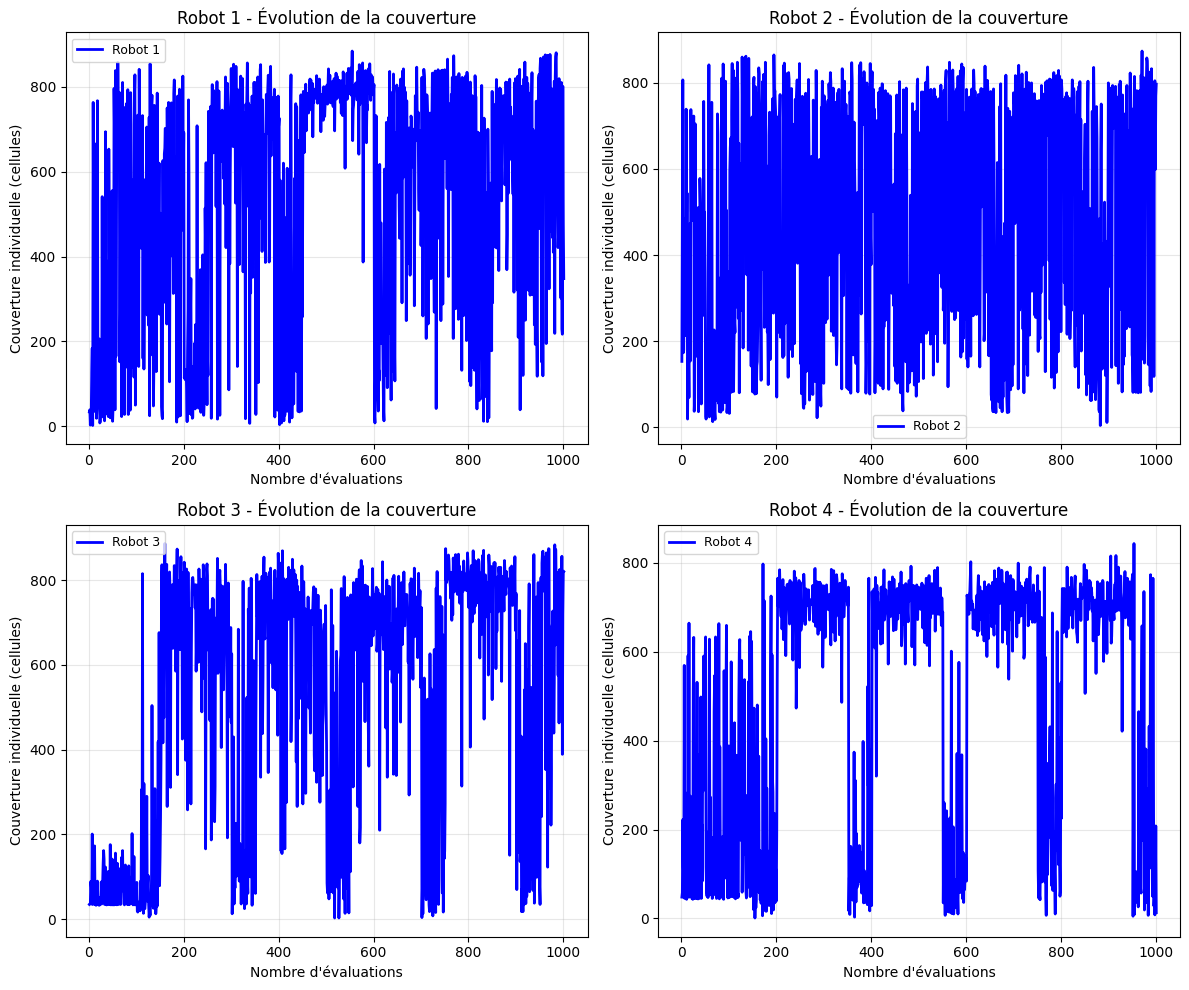


=== Meilleurs paramètres (poids) obtenus ===
Meilleure couverture totale finale : 1978.00
Robot 1 : [-1.458648734338106, -0.23877424632783267, 0.14717411339506653, -2.5449380334824028, 0.9598945911699561, -0.6106972992299701, 2.071880919887449, -0.6806270703188992, -1.3031309090558763, 0.9000623199045181]
Robot 2 : [-0.19834820962660826, 1.13842952775311, 0.4605157226374157, 1.458286297737239, 0.9109884858869766, -1.3033145041739869, -0.13319482765097926, 0.6079288078534515, -0.009767270920504778, 0.2809642333410998]
Robot 3 : [-0.856541000524979, 0.4391277188792242, 2.501769647774537, 0.9609024142822912, 0.9208351512988181, -1.0888359470062121, -0.722911195788999, 1.19763422922331, 0.4707571675775898, 0.5133615255599813]
Robot 4 : [0.03785187467427045, -0.23437267042130222, 0.013945012035242788, -1.2548933612603415, -0.6075658929707619, 0.13610728920092055, -0.25904531162917765, 0.7470873815024061, -0.4230779485395203, 0.6905305865776585]


Replay de l'équipe optimisée (positions alé

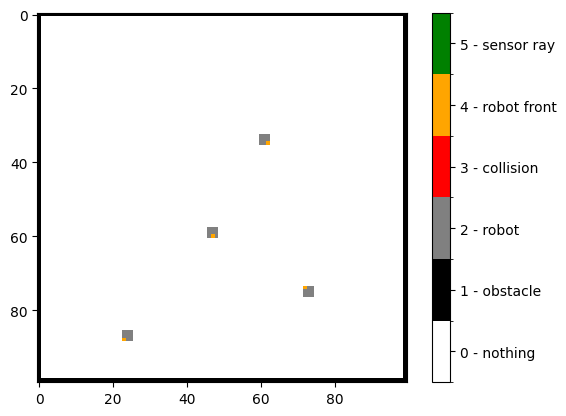

Trajectoires :


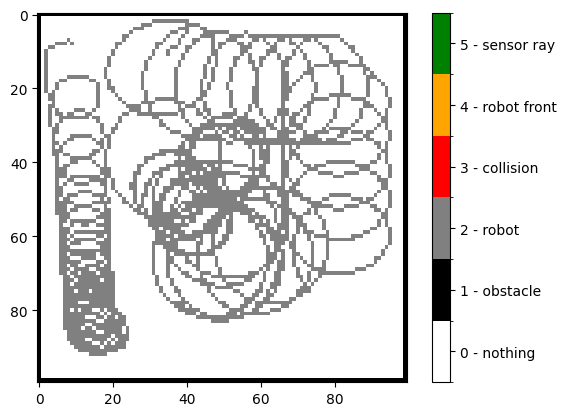


Terminé.


In [11]:
# ============================================================================
# Q5 : Équipe hétérogène – CMA‑ES par robot (fitness individuelle)
# Chaque robot optimise son propre score de couverture avec CMA‑ES.
# Stratégie : optimisation séquentielle en plusieurs tours.
# ============================================================================

# -------------------- Paramètres --------------------
arena_size = 100
max_iterations = 1001          # pas de simulation par évaluation
n_robots = 4
dim = 10                       # nombre de poids par robot

# Hyperparamètres CMA‑ES
sigma0 = 0.5                   # pas initial
n_rounds = 5                   # nombre de tours complets
evals_per_round_per_robot = 40 # évaluations par robot et par tour

total_evals_per_robot = n_rounds * evals_per_round_per_robot

# -------------------- Fonction d'évaluation individuelle --------------------
def evaluate_individual(robot_idx, candidate_weights):
    """
    Évalue l'équipe en fixant les autres robots à leurs meilleurs poids actuels.
    Retourne la couverture individuelle du robot `robot_idx`.
    (La fonction est appelée par CMA‑ES et doit être minimisée → retourne -coverage)
    """
    # Réinitialisation complète de l'environnement
    init()
    create_arena_walls()

    # Construction de la liste des poids pour tous les robots
    all_weights = best_weights.copy()
    all_weights[robot_idx] = candidate_weights

    # Placement des robots sans collision
    robots = []
    positions = []
    max_attempts = 100

    for i in range(n_robots):
        placed = False
        for _ in range(max_attempts):
            x = random.randint(particle_box, arena_size - particle_box - 1)
            y = random.randint(particle_box, arena_size - particle_box - 1)
            theta = random.uniform(-180, 180)

            collision = False
            for (px, py, _) in positions:
                if abs(x - px) < particle_box and abs(y - py) < particle_box:
                    collision = True
                    break

            if not collision:
                positions.append((x, y, theta))
                placed = True
                break
        if not placed:
            # Dernier recours : placement aléatoire sans vérification
            x = random.randint(particle_box, arena_size - particle_box - 1)
            y = random.randint(particle_box, arena_size - particle_box - 1)
            theta = random.uniform(-180, 180)
            positions.append((x, y, theta))

    for i in range(n_robots):
        robots.append(Robot_ANN(positions[i][0], positions[i][1], positions[i][2],
                                all_weights[i]))

    simulate(robots)

    # Récupération des couvertures individuelles
    individual_counts = [np.sum(occupancy == (i+1)) for i in range(n_robots)]
    total_coverage = sum(individual_counts)

    # Enregistrement des données pour les graphiques
    global eval_count, total_coverage_history, individual_fitness_history, eval_counts_history
    eval_count += 1
    total_coverage_history.append(total_coverage)
    eval_counts_history.append(eval_count)
    for i in range(n_robots):
        individual_fitness_history[i].append(individual_counts[i])

    # Retourne la couverture du robot concerné, négative pour minimisation
    return -individual_counts[robot_idx]

# -------------------- Initialisation de l'environnement --------------------
init()
create_arena_walls()

# -------------------- Initialisation des robots --------------------
best_weights = [np.random.uniform(-1, 1, size=dim).tolist() for _ in range(n_robots)]
best_ind_fitness = [0.0] * n_robots   # meilleure couverture individuelle actuelle

# Historiques pour les tracés
eval_count = 0
total_coverage_history = []
individual_fitness_history = [[] for _ in range(n_robots)]
eval_counts_history = []

# Évaluation initiale (pour initialiser best_ind_fitness)
print("Évaluation initiale...")
ind_fit, _ = evaluate_heterogeneous_team(best_weights)   # à définir (même que Q2)
eval_count = 1
for i in range(n_robots):
    best_ind_fitness[i] = ind_fit[i]

# Initialisation des historiques avec les valeurs initiales
total_coverage_history = [sum(ind_fit)]
eval_counts_history = [1]
for i in range(n_robots):
    individual_fitness_history[i].append(ind_fit[i])

print(f"Initial team coverage: {total_coverage_history[-1]:.2f}")

# -------------------- Optimisation par tours --------------------
print("\n" + "="*60)
print("Optimisation avec CMA‑ES par robot (multi‑tours)")
print("="*60)

for round_idx in range(n_rounds):
    print(f"\n--- Tour {round_idx+1}/{n_rounds} ---")
    for robot_idx in range(n_robots):
        print(f"  Optimisation du robot {robot_idx+1}...")
        # Point de départ = meilleur poids actuel de ce robot
        x0 = np.array(best_weights[robot_idx])

        # Création de l'instance CMA‑ES
        es = cma.CMAEvolutionStrategy(
            x0, sigma0,
            {'maxfevals': evals_per_round_per_robot,   # évaluations allouées pour ce tour
             'verbose': -1,                            # pas d'affichage
             'verb_disp': 0}
        )

        # Fonction objectif (minimisation)
        def objective(x):
            return evaluate_individual(robot_idx, x.tolist())

        # Optimisation
        es.optimize(objective)

        # Récupération du meilleur résultat
        best_param = es.result.xbest.tolist()
        best_fit = -es.result.fbest   # reconvertir en maximisation

        # Mise à jour des meilleurs poids
        if best_fit > best_ind_fitness[robot_idx]:
            best_weights[robot_idx] = best_param
            best_ind_fitness[robot_idx] = best_fit

        print(f"    Meilleure couverture robot {robot_idx+1} après ce tour : {best_fit:.2f}")

# -------------------- Tracé des résultats --------------------
# 1. Évolution de la couverture totale
plt.figure(figsize=(10,6))
plt.plot(eval_counts_history, total_coverage_history, 'g-', linewidth=2,
         label='Team coverage (sum)')
plt.xlabel("Nombre d'évaluations (simulate calls)", fontsize=12)
plt.ylabel("Couverture totale (cellules)", fontsize=12)
plt.title("Q5 : Équipe hétérogène – CMA‑ES par robot (fitness individuelle)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Évolution des couvertures individuelles (un sous‑graphique par robot)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(n_robots):
    ax = axes[i]
    ax.plot(eval_counts_history, individual_fitness_history[i], 'b-', linewidth=2,
            label=f'Robot {i+1}')
    ax.set_xlabel("Nombre d'évaluations", fontsize=10)
    ax.set_ylabel("Couverture individuelle (cellules)", fontsize=10)
    ax.set_title(f"Robot {i+1} - Évolution de la couverture", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# -------------------- Affichage des meilleurs paramètres --------------------
print("\n=== Meilleurs paramètres (poids) obtenus ===")
print(f"Meilleure couverture totale finale : {total_coverage_history[-1]:.2f}")
for i in range(n_robots):
    print(f"Robot {i+1} : {best_weights[i]}")
print("===========================================\n")

# -------------------- Replay de la meilleure équipe --------------------
print("\nReplay de l'équipe optimisée (positions aléatoires) :")
robots = []
for i in range(n_robots):
    x = random.randint(particle_box, arena_size - particle_box - 1)
    y = random.randint(particle_box, arena_size - particle_box - 1)
    theta = random.uniform(-180, 180)
    robots.append(Robot_ANN(x, y, theta, best_weights[i]))

ret = simulate(robots)
print("Statistiques finales :", ret)
print("État final :")
show_arena()
print("Trajectoires :")
show_trace()

print("\nTerminé.")

# Question 6

### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
Initial team coverage: 257.00
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
#

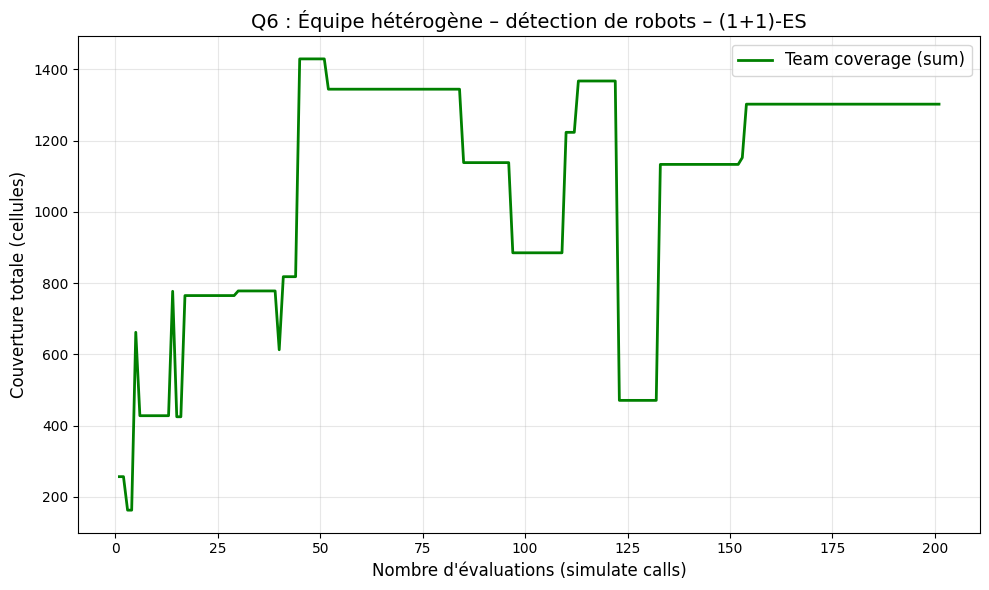

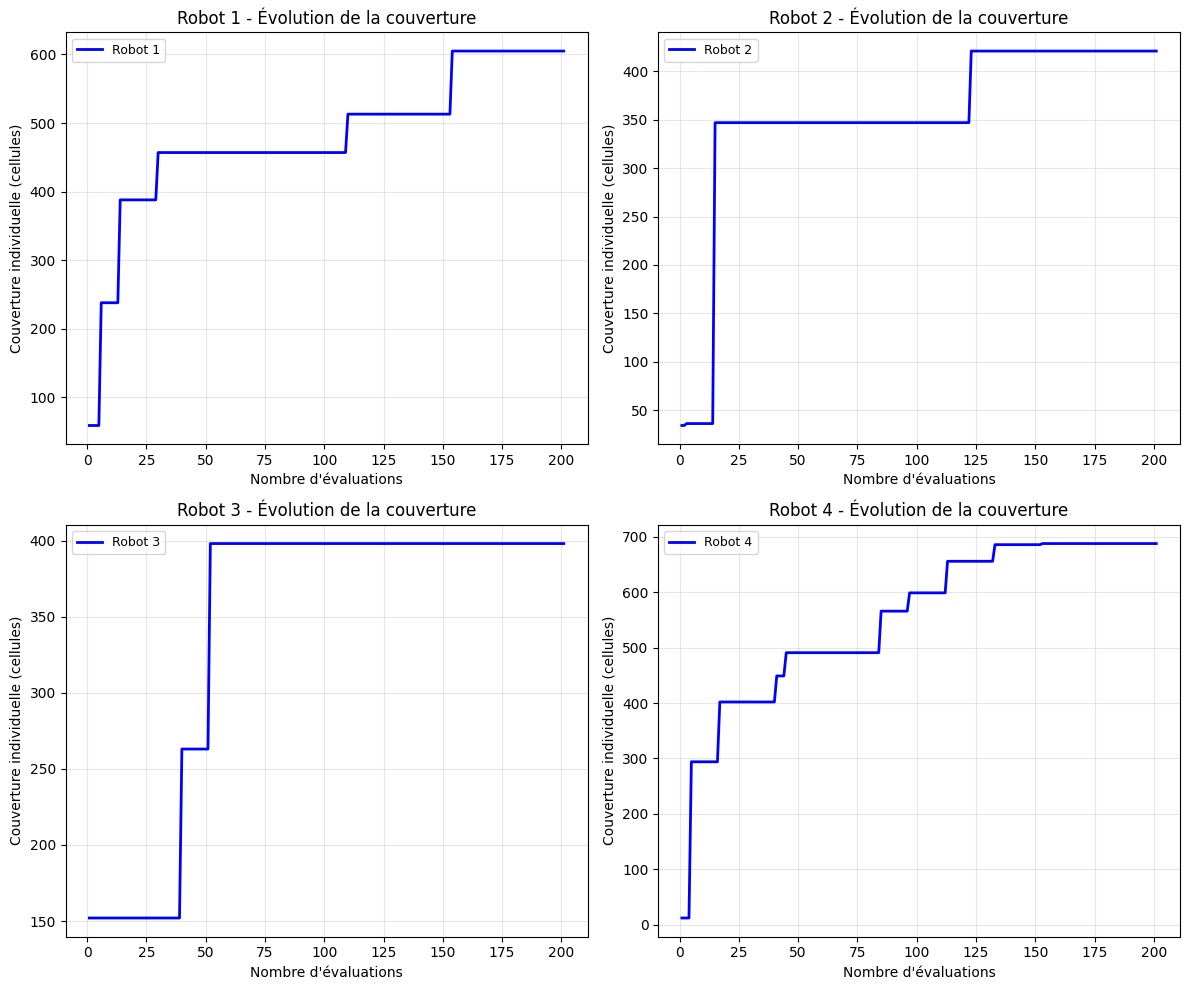


=== Meilleurs paramètres (poids) obtenus ===
Meilleure couverture totale finale : 1302.00
Robot 1 : [0.11185576525266389, -0.21629439557509142, -1.0, -1.0, 0.07933111975408239, -0.851162966728096, -0.06735634943397628, 0.6071648782545452, 0.3255381147679888, 0.19362109984585807, 0.8533247990401369, -0.42018803982624015, -0.9884581143830014, 0.43195260026052273, -1.0, 0.6160106094753519, 0.22709284869841373, -0.11081361825308805, 0.460297847253372, 1.0, -0.11938070847015746, -0.7520592283708164, 0.37506323370640393, -0.8106102425294592, -0.13979479111415596, -0.5908246398443984]
Robot 2 : [0.7887461603176336, 0.5465788841822262, 0.002508858480261264, 0.44799590249842414, 0.36146196987599477, 0.8395654709847095, 0.5468123051456475, -0.2814873153524712, 0.4596320718839616, 0.2835994670270068, -0.9094168177860518, -0.9795334541785813, 0.657517732334999, -0.11233373683503454, -0.294013534755322, -0.3447937529676099, 0.8571845152016931, 0.33881971311708814, 0.043378295217133975, 0.791807030

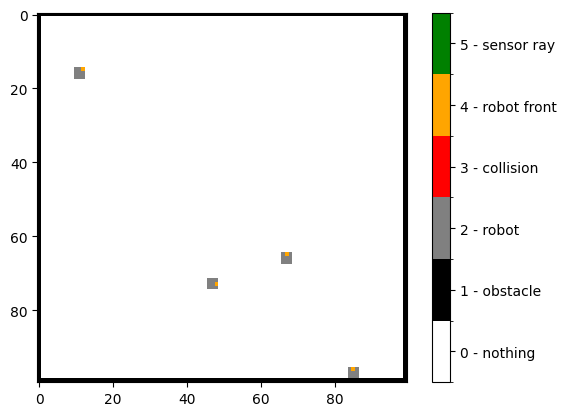

Trajectoires :


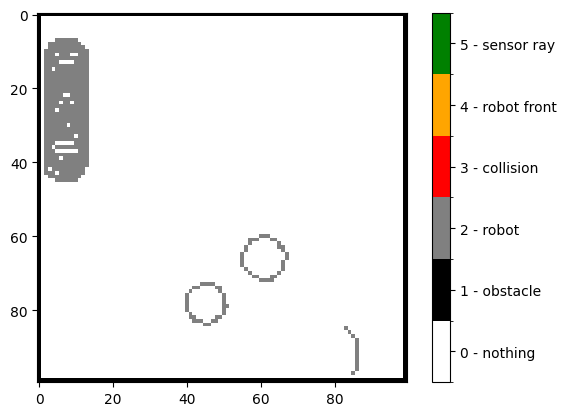


Terminé.


In [8]:
# ============================================================================
# Q6 : Équipe hétérogène avec détection de robots – (1+1)-ES
# ============================================================================

# --- 1. Redéfinition des fonctions de capture et de get_sensors avec détection robot ---
def cast_sensor_enhanced(x1, y1, x2, y2, color=6):
    global arena
    num_points = max(abs(x2 - x1), abs(y2 - y1)) + 1
    x_points = np.linspace(x1, x2, num_points, dtype=int)
    y_points = np.linspace(y1, y2, num_points, dtype=int)
    max_distance = math.sqrt((x_points[0]-x_points[-1])**2 + (y_points[0]-y_points[-1])**2) - particle_radius_real
    for i in range(len(x_points)):
        if 0 <= y_points[i] < arena.shape[0] and 0 <= x_points[i] < arena.shape[1]:
            cell = arena[y_points[i], x_points[i]]
            if cell == 1 or cell == 2 or cell == 4:
                dist = (math.sqrt((x_points[0]-x_points[i])**2 + (y_points[0]-y_points[i])**2) - particle_radius_real) / max_distance
                is_robot = (cell == 2 or cell == 4)
                return dist, is_robot
            elif display_cast:
                arena[y_points[i], x_points[i]] = color
    return 1.0, False

def get_sensors_enhanced(x, y, theta):
    source_x = int(x + particle_radius_real - 1)
    source_y = int(y + particle_radius_real - 1)
    distances = []
    robot_detected = []
    for i in range(nb_sensors):
        offset_x = math.cos(math.radians(theta + i*360.0/nb_sensors)) * sensor_length
        offset_y = math.sin(math.radians(theta + i*360.0/nb_sensors)) * sensor_length
        target_x = int(source_x + offset_x + 0.5)
        target_y = int(source_y - offset_y + 0.5)
        d, is_robot = cast_sensor_enhanced(source_x, source_y, target_x, target_y, 6)
        distances.append(d)
        robot_detected.append(1.0 if is_robot else 0.0)
    return distances + robot_detected   # 16 valeurs

# --- 2. Nouvelle classe de robot avec 26 poids ---
class Robot_ANN_Enhanced(Robot):
    def __init__(self, x_0, y_0, theta_0, weights):
        # weights : liste de 26 poids
        self.weights = weights[:]
        super().__init__(x_0, y_0, theta_0)

    def step(self, sensors):
        # sensors : 16 valeurs (8 distances + 8 indicateurs robot)
        # translation : 16 poids + 1 biais
        trans = (self.weights[0]*sensors[0] + self.weights[1]*sensors[1] +
                 self.weights[2]*sensors[2] + self.weights[3]*sensors[3] +
                 self.weights[4]*sensors[4] + self.weights[5]*sensors[5] +
                 self.weights[6]*sensors[6] + self.weights[7]*sensors[7] +
                 self.weights[8]*sensors[8] + self.weights[9]*sensors[9] +
                 self.weights[10]*sensors[10] + self.weights[11]*sensors[11] +
                 self.weights[12]*sensors[12] + self.weights[13]*sensors[13] +
                 self.weights[14]*sensors[14] + self.weights[15]*sensors[15] +
                 self.weights[16])
        # rotation : 8 distances + 1 biais
        rot = (self.weights[17]*sensors[0] + self.weights[18]*sensors[1] +
               self.weights[19]*sensors[2] + self.weights[20]*sensors[3] +
               self.weights[21]*sensors[4] + self.weights[22]*sensors[5] +
               self.weights[23]*sensors[6] + self.weights[24]*sensors[7] +
               self.weights[25])
        return trans, rot

# --- 3. Fonction simulate_enhanced (copie modifiée de simulate) ---
def simulate_enhanced(my_robots):
    global x_particle, y_particle, absolute_orientation, trace, occupancy
    clear_arena()
    clear_trace()
    clear_occupancy()

    for k in range(len(my_robots)):
        collision_array = place_particle(my_robots[k].x, my_robots[k].y, my_robots[k].theta, my_robots[k].id)
        if collision_array is not None:
            print("[ERROR] initial location triggers collision.")
            sys.exit()

    iteration = 0
    while iteration < max_iterations:
        if verbose_minimal_progress and iteration % gap_between_display_minimal_progress == 0:
            print("### iteration", iteration, "/", max_iterations, "###")

        for k in range(len(my_robots)):
            erase_particle(my_robots[k].x, my_robots[k].y)
            clean_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
            sensors = get_sensors_enhanced(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
            translation_per_step, rotation_per_step = my_robots[k].step(sensors)

            my_robots[k].log_sum_of_rotation += abs(max(-1., min(+1., rotation_per_step)))

            backup_x_particle, backup_y_particle = my_robots[k].x, my_robots[k].y
            my_robots[k].x, my_robots[k].y, my_robots[k].theta = update_particle_position(
                my_robots[k].x, my_robots[k].y, my_robots[k].theta,
                max(-1., min(+1., translation_per_step))*max_translation_per_step,
                max(-1., min(+1., rotation_per_step))*max_rotation_per_step,
                iteration, noiseFlag=False)
            sensors = get_sensors_enhanced(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
            collision_array = place_particle(my_robots[k].x, my_robots[k].y, my_robots[k].theta, my_robots[k].id)
            if collision_array is not None:
                if verbose:
                    print("Collision detected!")
                if display_collision:
                    print(collision_array)
                clean_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
                my_robots[k].x, my_robots[k].y = backup_x_particle, backup_y_particle
                sensors = get_sensors_enhanced(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
                if display_collision:
                    draw(collision_array)
                my_robots[k].theta = update_particle_dynamics(
                    my_robots[k].x, my_robots[k].y, my_robots[k].theta,
                    max(-1., min(+1., translation_per_step))*max_translation_per_step,
                    max(-1., min(+1., rotation_per_step))*max_rotation_per_step,
                    iteration, collision_array)
                place_particle(my_robots[k].x, my_robots[k].y, my_robots[k].theta, my_robots[k].id)
                if verbose:
                    print("Backtrack")

            if my_robots[k].x != backup_x_particle or my_robots[k].y != backup_y_particle:
                my_robots[k].log_sum_of_translation += math.sqrt((my_robots[k].x - backup_x_particle)**2 +
                                                                 (my_robots[k].y - backup_y_particle)**2)

        if display_arena:
            draw(arena)
        if verbose:
            print(arena)
        iteration += 1

    log_pixels_visited = np.sum(trace == 2)
    log_total_sum_of_translation, log_total_sum_of_rotation = 0, 0
    for k in range(len(my_robots)):
        log_total_sum_of_translation += my_robots[k].log_sum_of_translation
        log_total_sum_of_rotation += my_robots[k].log_sum_of_rotation

    retValues = {
        "translations": log_total_sum_of_translation / max_iterations,
        "rotations": log_total_sum_of_rotation / max_iterations,
        "coverage": log_pixels_visited / (arena_size**2)
    }
    return retValues

# --- 4. Évaluation d'une équipe hétérogène avec le nouveau simulateur ---
def evaluate_heterogeneous_team_enhanced(weights_list):
    # Réinitialisation
    init()
    create_arena_walls()

    robots = []
    positions = []
    max_attempts = 100

    for i in range(n_robots):
        placed = False
        for _ in range(max_attempts):
            x = random.randint(particle_box, arena_size - particle_box - 1)
            y = random.randint(particle_box, arena_size - particle_box - 1)
            theta = random.uniform(-180, 180)

            collision = False
            for (px, py, _) in positions:
                if abs(x - px) < particle_box and abs(y - py) < particle_box:
                    collision = True
                    break
            if not collision:
                positions.append((x, y, theta))
                placed = True
                break
        if not placed:
            x = random.randint(particle_box, arena_size - particle_box - 1)
            y = random.randint(particle_box, arena_size - particle_box - 1)
            theta = random.uniform(-180, 180)
            positions.append((x, y, theta))

    for i in range(n_robots):
        robots.append(Robot_ANN_Enhanced(positions[i][0], positions[i][1],
                                         positions[i][2], weights_list[i]))

    ret = simulate_enhanced(robots)
    # Récupération des couvertures individuelles
    individual_counts = [np.sum(occupancy == (i+1)) for i in range(n_robots)]
    total_coverage = sum(individual_counts)
    return individual_counts, total_coverage

# --- 5. Paramètres ---
n_robots = 4
n_updates_per_robot = 50
sigma = 0.1
max_iterations = 1001

# --- 6. Initialisation de l'environnement ---
init()
create_arena_walls()

# --- 7. Optimisation (1+1)-ES par robot ---
# 26 poids par robot (16 pour les entrées translation + biais, 8 pour les distances rotation + biais)
current_weights = [np.random.uniform(-1, 1, size=26).tolist() for _ in range(n_robots)]
best_weights = [w[:] for w in current_weights]
best_ind_fitness = [0.0] * n_robots
current_ind_fitness = [0.0] * n_robots

# Historiques
total_coverage_history = []
eval_counts_history = []
individual_fitness_history = [[] for _ in range(n_robots)]
eval_count = 0

# Évaluation initiale
ind_fit, total_fit = evaluate_heterogeneous_team_enhanced(current_weights)
eval_count += 1
for i in range(n_robots):
    best_ind_fitness[i] = ind_fit[i]
current_ind_fitness = ind_fit.copy()
current_total_fitness = total_fit
total_coverage_history.append(current_total_fitness)
eval_counts_history.append(eval_count)
for i in range(n_robots):
    individual_fitness_history[i].append(current_ind_fitness[i])

print(f"Initial team coverage: {current_total_fitness:.2f}")

# Boucle d'optimisation
total_updates = n_robots * n_updates_per_robot
update_count = 0

while update_count < total_updates:
    robot_idx = update_count % n_robots

    # Mutation du robot courant
    child_weights = [w[:] for w in current_weights]
    child_weights[robot_idx] = [w + np.random.normal(0, sigma) for w in current_weights[robot_idx]]
    child_weights[robot_idx] = np.clip(child_weights[robot_idx], -1, 1).tolist()

    ind_fit, total_fit = evaluate_heterogeneous_team_enhanced(child_weights)
    eval_count += 1

    if ind_fit[robot_idx] >= best_ind_fitness[robot_idx]:
        current_weights[robot_idx] = child_weights[robot_idx]
        best_weights[robot_idx] = child_weights[robot_idx]
        best_ind_fitness[robot_idx] = ind_fit[robot_idx]
        current_total_fitness = total_fit
        current_ind_fitness[robot_idx] = ind_fit[robot_idx]

    total_coverage_history.append(current_total_fitness)
    eval_counts_history.append(eval_count)
    for i in range(n_robots):
        individual_fitness_history[i].append(current_ind_fitness[i])

    update_count += 1
    if update_count % (n_robots * (n_updates_per_robot // 10)) == 0 and n_updates_per_robot // 10 > 0:
        print(f"Updates done: {update_count}/{total_updates} – current team coverage: {current_total_fitness:.2f}")

# --- 8. Tracés ---
plt.figure(figsize=(10,6))
plt.plot(eval_counts_history, total_coverage_history, 'g-', linewidth=2, label='Team coverage (sum)')
plt.xlabel("Nombre d'évaluations (simulate calls)", fontsize=12)
plt.ylabel("Couverture totale (cellules)", fontsize=12)
plt.title("Q6 : Équipe hétérogène – détection de robots – (1+1)-ES", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i in range(n_robots):
    ax = axes[i]
    ax.plot(eval_counts_history, individual_fitness_history[i], 'b-', linewidth=2, label=f'Robot {i+1}')
    ax.set_xlabel("Nombre d'évaluations", fontsize=10)
    ax.set_ylabel("Couverture individuelle (cellules)", fontsize=10)
    ax.set_title(f"Robot {i+1} - Évolution de la couverture", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- 9. Affichage des meilleurs paramètres ---
print("\n=== Meilleurs paramètres (poids) obtenus ===")
print(f"Meilleure couverture totale finale : {current_total_fitness:.2f}")
for i in range(n_robots):
    print(f"Robot {i+1} : {best_weights[i]}")
print("===========================================\n")

# --- 10. Replay de la meilleure équipe ---
print("\nReplay de l'équipe optimisée (positions aléatoires) :")
robots = []
for i in range(n_robots):
    x = random.randint(particle_box, arena_size - particle_box - 1)
    y = random.randint(particle_box, arena_size - particle_box - 1)
    theta = random.uniform(-180, 180)
    robots.append(Robot_ANN_Enhanced(x, y, theta, best_weights[i]))

ret = simulate_enhanced(robots)
print("Statistiques finales :", ret)
print("État final :")
show_arena()
print("Trajectoires :")
show_trace()
print("\nTerminé.")

---
---
---

#<font color="orange">Fin du sujet.</font>

---
---
---
